# Başlangıç Beyin Segmentasyonu Denemeleri

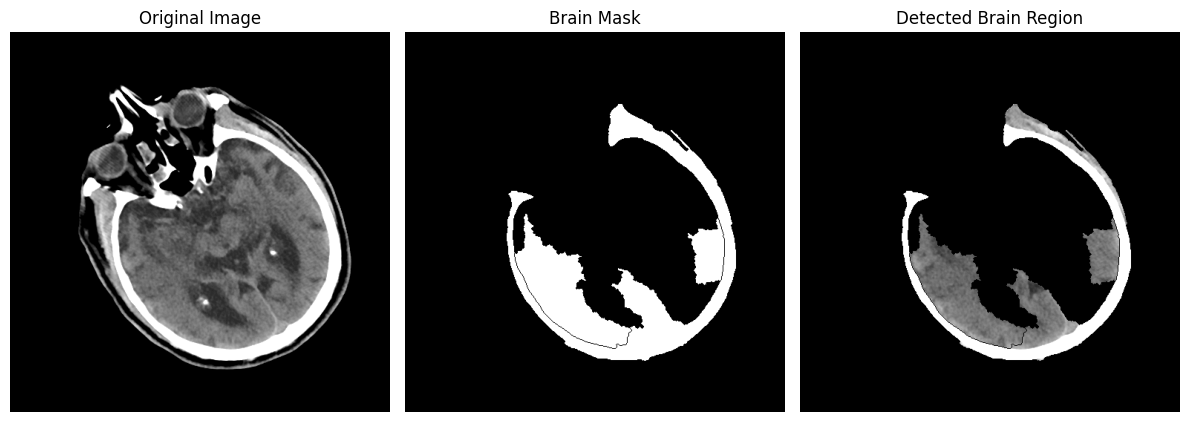

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Load the brain CT image in grayscale
image = cv2.imread('data/BeyinInmeVerisi-Siniflandirma/1/12161.png', cv2.IMREAD_GRAYSCALE)

# Apply Otsu's thresholding to segment the image
_, thresh = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Remove noise using morphological operations
kernel = np.ones((5, 5), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Find sure background area
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Find sure foreground area
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)

# Find unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Marker labelling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Apply watershed algorithm
color_img = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(color_img, markers)

# Create a mask for the brain region
brain_mask = np.zeros_like(image)
brain_mask[markers > 1] = 255

# Apply the mask to the original image
brain_only = cv2.bitwise_and(image, image, mask=brain_mask)

# Display results
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(brain_mask, cmap='gray')
plt.title('Brain Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(brain_only, cmap='gray')
plt.title('Detected Brain Region')
plt.axis('off')

plt.tight_layout()
plt.show()

# İyileştirilmiş Beyin Segmentasyonu

Kafatası kemiğini (beyaz parlak kısım) hariç tutarak yalnızca beyin dokusunu segmente etmek için iyileştirilmiş bir yaklaşım uygulayacağız. BT görüntülerinde kafatası genellikle en yüksek yoğunluk (en parlak) değerlerine sahiptir.

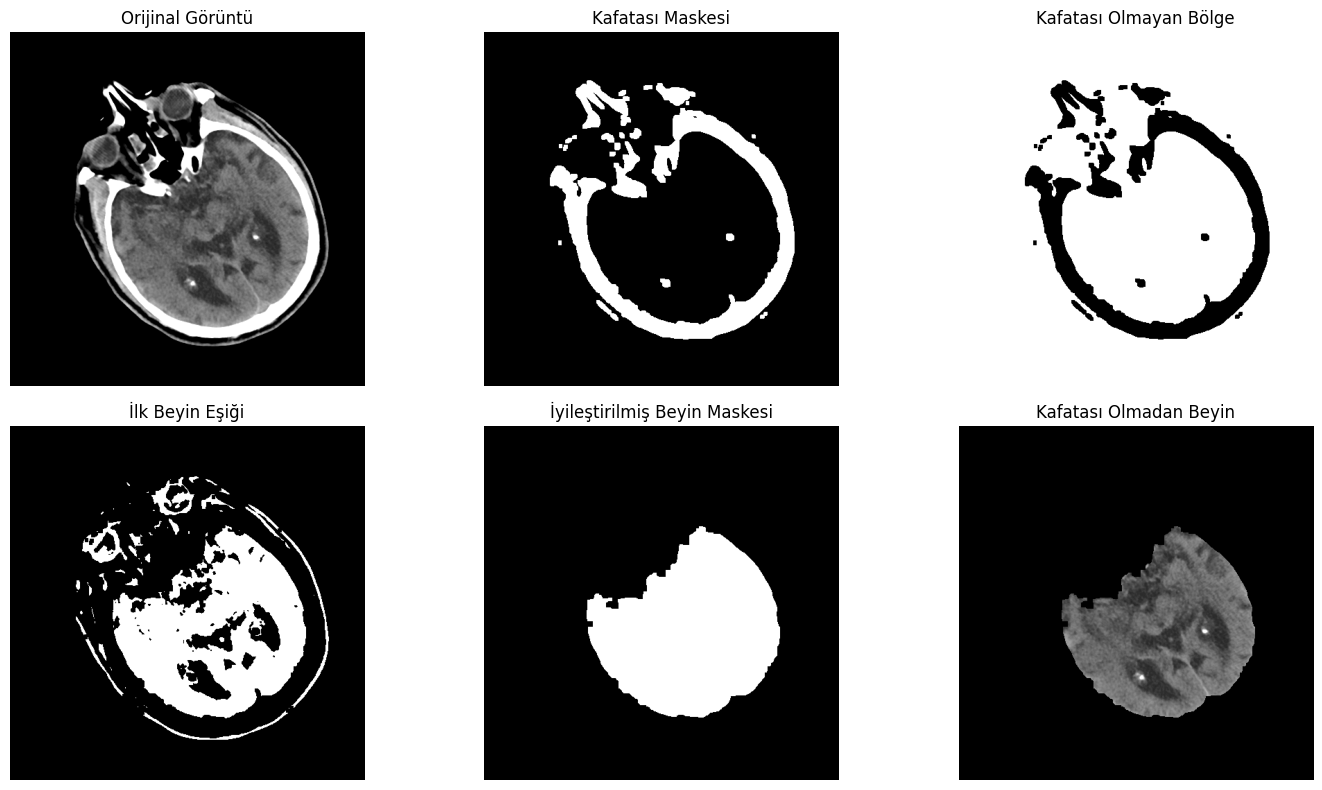

In [2]:
# İyileştirilmiş Beyin Segmentasyonu
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Görüntüyü yeniden yükle
image = cv2.imread('data/BeyinInmeVerisi-Siniflandirma/1/12161.png', cv2.IMREAD_GRAYSCALE)

# 2. Görüntüyü düzgünleştir
blurred = cv2.GaussianBlur(image, (5, 5), 0)

# 3. Kafatasını tespit etmek için eşik değeri belirleme (yüksek yoğunluk değerlerine sahip)
# BT görüntüsünde kafatası genellikle en parlak bölgedir
_, skull_thresh = cv2.threshold(blurred, 160, 255, cv2.THRESH_BINARY)

# 4. Kafatası maskelemesini genişlet
kernel = np.ones((3, 3), np.uint8)
skull_mask = cv2.dilate(skull_thresh, kernel, iterations=2)

# 5. Kafatası olmayan tüm bölge
non_skull = cv2.bitwise_not(skull_mask)

# 6. Beyin bölgesini tespit etmek için eşik değeri belirleme
# (kafatası olmayan bölgenin orta yoğunluklu kısmını alıyoruz)
_, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=non_skull),
                              70, 255, cv2.THRESH_BINARY)

# 7. Morfolojik işlemler kullanarak gürültüyü gider ve boşlukları doldur
brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, kernel, iterations=2)

# 8. En büyük bağlantılı bileşeni bul (beyin bölgesi)
contours, _ = cv2.findContours(brain_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if contours:
    # En büyük konturu bul
    largest_contour = max(contours, key=cv2.contourArea)

    # Sadece en büyük kontur için maske oluştur
    refined_brain_mask = np.zeros_like(brain_mask)
    cv2.drawContours(refined_brain_mask, [largest_contour], 0, 255, -1)

    # Maskeyi uygula
    brain_only_refined = cv2.bitwise_and(image, image, mask=refined_brain_mask)
else:
    refined_brain_mask = brain_mask
    brain_only_refined = cv2.bitwise_and(image, image, mask=brain_mask)

# 9. Sonuçları göster
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Orijinal Görüntü')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(skull_mask, cmap='gray')
plt.title('Kafatası Maskesi')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(non_skull, cmap='gray')
plt.title('Kafatası Olmayan Bölge')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(brain_thresh, cmap='gray')
plt.title('İlk Beyin Eşiği')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(refined_brain_mask, cmap='gray')
plt.title('İyileştirilmiş Beyin Maskesi')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(brain_only_refined, cmap='gray')
plt.title('Kafatası Olmadan Beyin')
plt.axis('off')

plt.tight_layout()
plt.show()

# Parametreleri Ayarlama

Eşik değerlerini ve morfolojik işlemleri ayarlayarak sonucu iyileştirebiliriz.

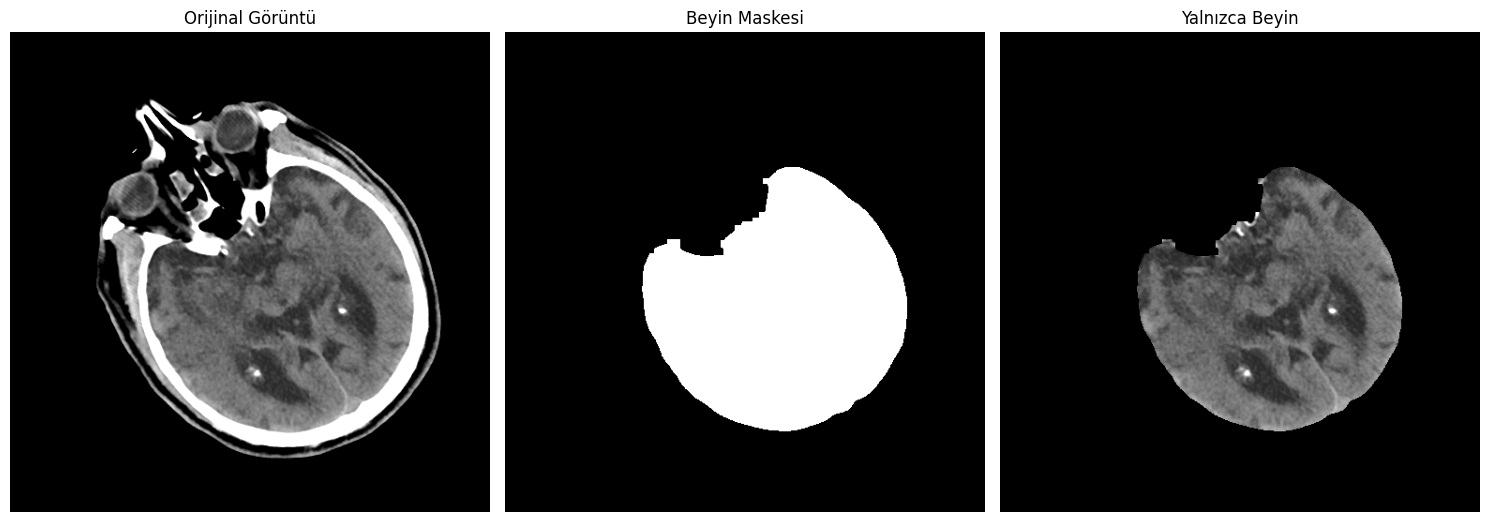

In [3]:
# Parametreleri ayarlayarak beyin segmentasyonunu iyileştir ve inme bölgelerini tespit et
def segment_brain_and_detect_stroke(image_path, skull_threshold=230, brain_threshold=50):
    # Görüntüyü yükle
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Hata: {image_path} yüklenemedi!")
        return None, None, None, None

    # Görüntüyü düzgünleştir
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Kafatasını tespit et
    _, skull_thresh = cv2.threshold(blurred, skull_threshold, 255, cv2.THRESH_BINARY)
    kernel = np.ones((3, 3), np.uint8)
    skull_mask = cv2.dilate(skull_thresh, kernel, iterations=2)
    non_skull = cv2.bitwise_not(skull_mask)

    # Beyin bölgesini tespit et
    _, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=non_skull),
                                  brain_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemler
    brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, kernel, iterations=2)

# 8. En büyük bağlantılı bileşeni bul
    contours, _ = cv2.findContours(brain_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        final_brain_mask = np.zeros_like(brain_mask)
        cv2.drawContours(final_brain_mask, [largest_contour], 0, 255, -1)
    else:
        final_brain_mask = brain_mask

    # Beyin bölgesini çıkar
    brain_only = cv2.bitwise_and(image, image, mask=final_brain_mask)


    return image, final_brain_mask, brain_only

# Test et
results = segment_brain_and_detect_stroke('data/BeyinInmeVerisi-Siniflandirma/1/12161.png')

if results is not None and len(results) >= 3:
    image, brain_mask, brain_only = results

    plt.figure(figsize=(15, 10))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Orijinal Görüntü')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(brain_mask, cmap='gray')
    plt.title('Beyin Maskesi')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(brain_only, cmap='gray')
    plt.title('Yalnızca Beyin')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Çoklu Beyin Bölgelerinin Tespiti

Bazı BT görüntülerinde beyin dokusu, kafatası kemiğinin araya girmesiyle birden fazla parçaya ayrılabilir. Bu durumda, yalnızca en büyük bağlantılı bileşeni almak yerine, belirli bir boyutun üzerindeki tüm beyin parçalarını tespit etmemiz gerekiyor.

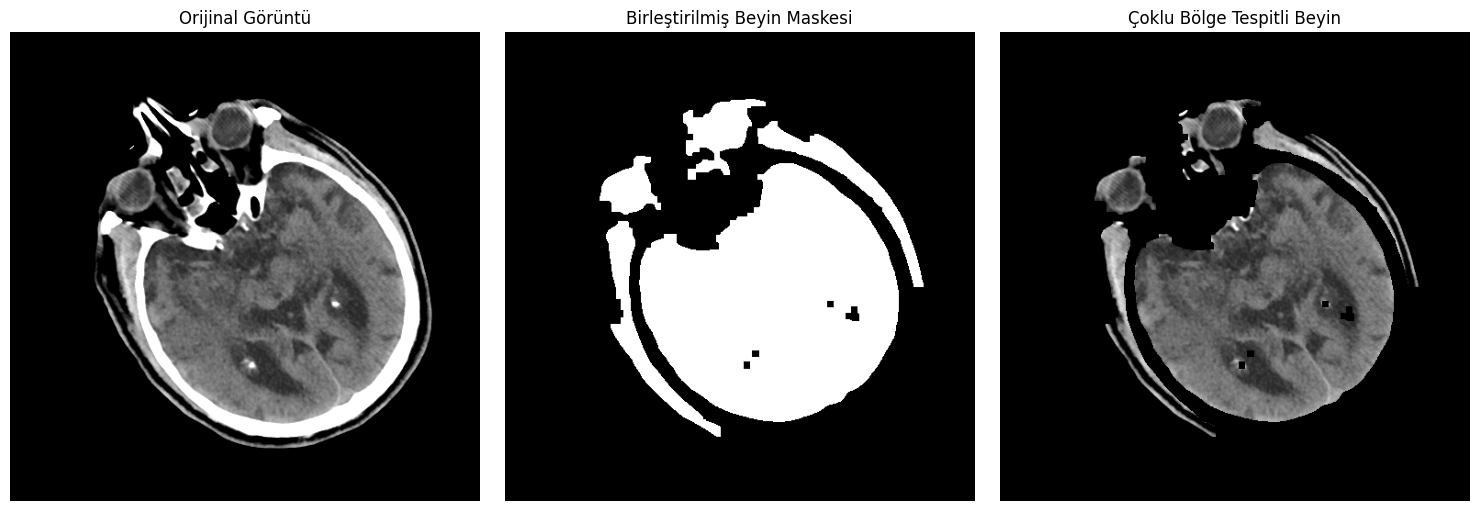

In [4]:
# Çoklu beyin bölgelerini tespit edebilen geliştirilmiş fonksiyon
def segment_brain_with_multiple_regions(image_path, skull_threshold=230, brain_threshold=50, min_region_size=500):
    # Görüntüyü yükle
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Hata: {image_path} yüklenemedi!")
        return None, None, None

    # Görüntüyü düzgünleştir
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Kafatasını tespit et
    _, skull_thresh = cv2.threshold(blurred, skull_threshold, 255, cv2.THRESH_BINARY)
    kernel = np.ones((3, 3), np.uint8)
    skull_mask = cv2.dilate(skull_thresh, kernel, iterations=2)
    non_skull = cv2.bitwise_not(skull_mask)

    # Beyin bölgesini tespit et
    _, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=non_skull),
                                  brain_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemler
    brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, kernel, iterations=2)

    # Tüm bağlantılı bileşenleri bul
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(brain_mask, connectivity=8)

    # Birleşik beyin maskesi oluştur
    combined_brain_mask = np.zeros_like(brain_mask)

    # İlk etiket arka plan olduğu için 1'den başla
    for label in range(1, num_labels):
        # Bileşenin alanını kontrol et
        area = stats[label, cv2.CC_STAT_AREA]

        # Belirli bir boyuttan büyük olan bileşenleri ekle
        if area > min_region_size:
            current_mask = (labels == label).astype(np.uint8) * 255
            combined_brain_mask = cv2.bitwise_or(combined_brain_mask, current_mask)

    # Delikli bölgeleri doldur (beyin ventriküllerini korumak için dikkatli olalım)
    # Doldurma işlemi büyük kafatası boşluklarını da doldurabilir, bu nedenle sınırlı kullan
    # Bu kısmı ihtiyaca göre aktifleştirebiliriz
    # combined_brain_mask = cv2.morphologyEx(combined_brain_mask, cv2.MORPH_CLOSE,
    #                                       np.ones((5,5),np.uint8), iterations=2)

    # Beyin bölgesini çıkar
    brain_only = cv2.bitwise_and(image, image, mask=combined_brain_mask)

    return image, combined_brain_mask, brain_only

# Test et - parametreleri değiştirerek farklı görüntüleri dene
image_path = 'data/BeyinInmeVerisi-Siniflandirma/1/12161.png'
orig_img, brain_mask, brain_extracted = segment_brain_with_multiple_regions(image_path,
                                                                 skull_threshold=230,
                                                                 brain_threshold=50,
                                                                 min_region_size=800)

if orig_img is not None:
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(orig_img, cmap='gray')
    plt.title('Orijinal Görüntü')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(brain_mask, cmap='gray')
    plt.title('Birleştirilmiş Beyin Maskesi')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(brain_extracted, cmap='gray')
    plt.title('Çoklu Bölge Tespitli Beyin')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Sadece Kafatası İçindeki Beyin Bölgelerinin Tespiti

Önceki yöntemimiz beyin bölgelerini tespit edebiliyordu ancak gözler gibi kafatası dışında kalan istenmeyen bölgeleri de beyin olarak algılıyordu. Bu problemi çözmek için:

1. Öncelikle kafatası çevresini (konturu) belirleyeceğiz
2. Bu kontur içinde kalan bölgeyi kafatası boşluğu olarak tanımlayacağız
3. Sadece bu boşluğun içindeki beyin dokusunu tespit edeceğiz

Bu yaklaşım, gözler ve diğer kafatası dışındaki yumuşak dokular gibi istenmeyen bölgelerin tespit edilmesini önleyecektir.

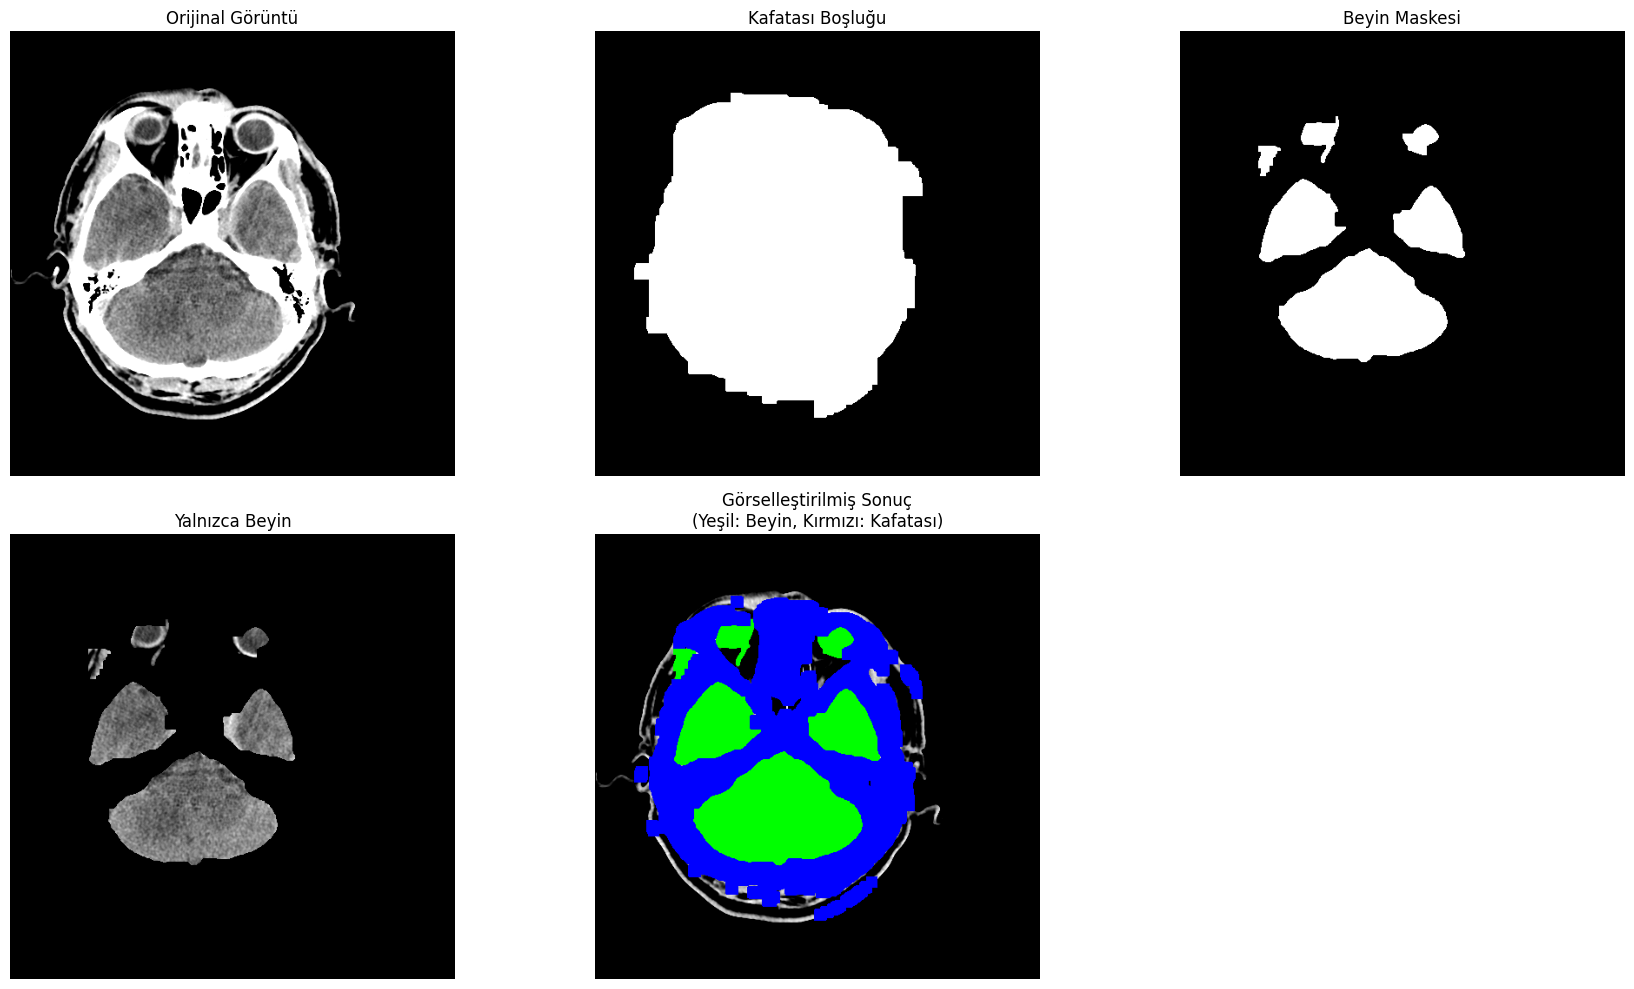

In [5]:
# Kafatası içindeki beyin bölgelerini tespit eden geliştirilmiş fonksiyon
def segment_brain_inside_skull(image_path, skull_threshold=230, brain_threshold=50):
    # Görüntüyü yükle
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Hata: {image_path} yüklenemedi!")
        return None, None, None, None

    # 1. Kafatası konturu belirleme
    # Önce görüntüyü yumuşatma
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Kafatasının yüksek yoğunluklu bölgelerini tespit et
    _, skull_thresh = cv2.threshold(blurred, skull_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle kafatasını kalınlaştır
    kernel = np.ones((5, 5), np.uint8)
    skull_dilated = cv2.dilate(skull_thresh, kernel, iterations=3)

    # 2. Kafatası konturunun içini doldur (kafatası boşluğunu elde et)
    # Önce büyük bir kontur elde etmek için morfolojik işlemlerle kapatma
    skull_closed = cv2.morphologyEx(skull_dilated, cv2.MORPH_CLOSE, kernel, iterations=10)

    # Kafatası boşluğunu içerecek şekilde tüm konturları bul
    contours, _ = cv2.findContours(skull_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Kafatası konturu için boş bir maske oluştur
    skull_cavity_mask = np.zeros_like(image)

    # En büyük konturu kafatası olarak varsay ve içini doldur
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(skull_cavity_mask, [largest_contour], 0, 255, -1)

    # 3. Beyin bölgesini tespit et
    # Kafatası içindeki bölgelere odaklan (kafatası olmayan bölgeyi al)
    non_skull = cv2.bitwise_not(skull_dilated)

    # Kafatası boşluğu VE kafatası olmayan bölge = sadece kafatası içindeki yumuşak doku
    inner_region = cv2.bitwise_and(skull_cavity_mask, non_skull)

    # Beyin dokusunu diğer yumuşak dokulardan ayırmak için eşikleme
    _, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=inner_region),
                                  brain_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle beyin bölgesini temizle
    brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=2)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)

    # 4. Büyük bağlantılı beyin bölgelerini seç
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(brain_mask, connectivity=8)

    # Birleşik beyin maskesi oluştur, sadece belirli bir boyuttan büyük bileşenleri al
    min_region_size = 500  # Gerçek uygulamada bu değeri ayarlamak gerekebilir
    final_brain_mask = np.zeros_like(brain_mask)

    # İlk etiket arka plan olduğu için 1'den başla
    for label in range(1, num_labels):
        area = stats[label, cv2.CC_STAT_AREA]
        if area > min_region_size:
            current_mask = (labels == label).astype(np.uint8) * 255
            final_brain_mask = cv2.bitwise_or(final_brain_mask, current_mask)

    # Beyin bölgesini çıkar
    brain_only = cv2.bitwise_and(image, image, mask=final_brain_mask)

    # Görselleştirme için renkli sonuç hazırla
    colored_result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    colored_result[final_brain_mask > 0] = [0, 255, 0]  # Beyin bölgesi yeşil
    colored_result[skull_dilated > 0] = [0, 0, 255]  # Kafatası kırmızı

    return image, skull_cavity_mask, final_brain_mask, brain_only, colored_result

# Test et
image_path = 'data/BeyinInmeVerisi-Siniflandirma/1/10394.png'
results = segment_brain_inside_skull(image_path, skull_threshold=230, brain_threshold=40)

if results is not None and len(results) >= 5:
    orig_img, skull_cavity, brain_mask, brain_only, colored_vis = results

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(orig_img, cmap='gray')
    plt.title('Orijinal Görüntü')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(skull_cavity, cmap='gray')
    plt.title('Kafatası Boşluğu')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(brain_mask, cmap='gray')
    plt.title('Beyin Maskesi')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(brain_only, cmap='gray')
    plt.title('Yalnızca Beyin')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(colored_vis)
    plt.title('Görselleştirilmiş Sonuç\n(Yeşil: Beyin, Kırmızı: Kafatası)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Kafatası İçindeki Max Alana Sahip 3 Bölgeyi Al

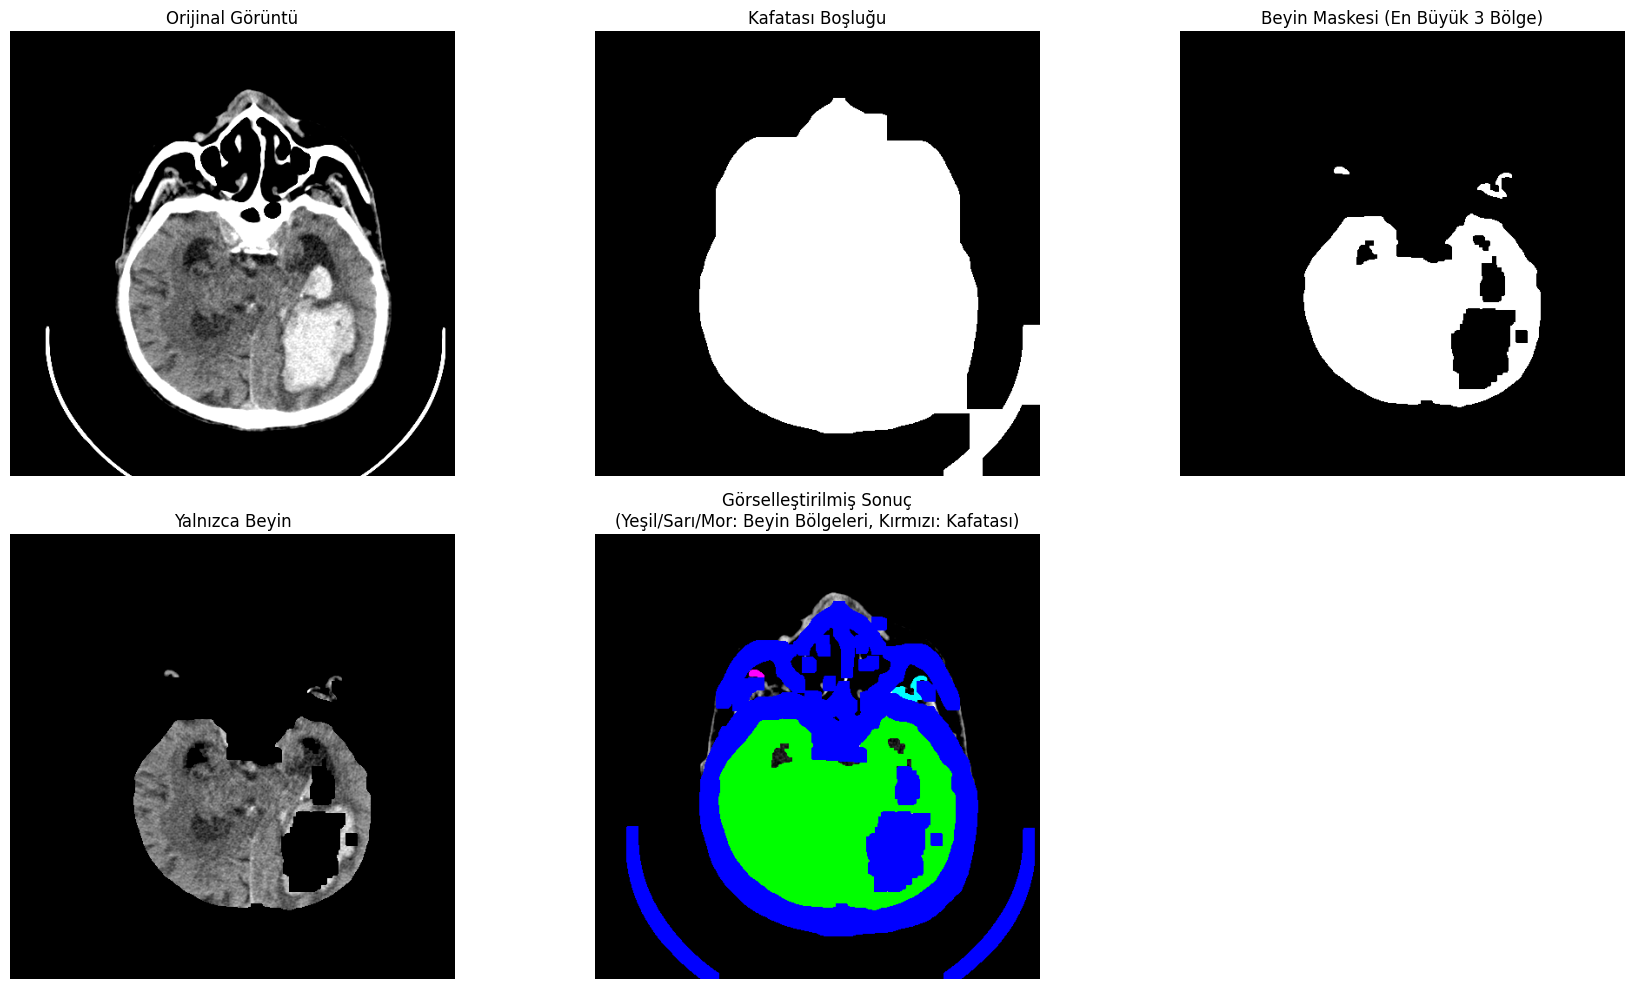

In [6]:
# Kafatası içindeki beyin bölgelerini tespit eden geliştirilmiş fonksiyon (max 3 bölge)
def segment_brain_inside_skull(image_path, skull_threshold=230, brain_threshold=50, max_regions=3):
    # Görüntüyü yükle
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Hata: {image_path} yüklenemedi!")
        return None, None, None, None, None

    # 1. Kafatası konturu belirleme
    # Önce görüntüyü yumuşatma
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Kafatasının yüksek yoğunluklu bölgelerini tespit et
    _, skull_thresh = cv2.threshold(blurred, skull_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle kafatasını kalınlaştır
    kernel = np.ones((5, 5), np.uint8)
    skull_dilated = cv2.dilate(skull_thresh, kernel, iterations=3)

    # 2. Kafatası konturunun içini doldur (kafatası boşluğunu elde et)
    # Önce büyük bir kontur elde etmek için morfolojik işlemlerle kapatma
    skull_closed = cv2.morphologyEx(skull_dilated, cv2.MORPH_CLOSE, kernel, iterations=10)

    # Kafatası boşluğunu içerecek şekilde tüm konturları bul
    contours, _ = cv2.findContours(skull_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Kafatası konturu için boş bir maske oluştur
    skull_cavity_mask = np.zeros_like(image)

    # En büyük konturu kafatası olarak varsay ve içini doldur
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(skull_cavity_mask, [largest_contour], 0, 255, -1)

    # 3. Beyin bölgesini tespit et
    # Kafatası içindeki bölgelere odaklan (kafatası olmayan bölgeyi al)
    non_skull = cv2.bitwise_not(skull_dilated)

    # Kafatası boşluğu VE kafatası olmayan bölge = sadece kafatası içindeki yumuşak doku
    inner_region = cv2.bitwise_and(skull_cavity_mask, non_skull)

    # Beyin dokusunu diğer yumuşak dokulardan ayırmak için eşikleme
    _, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=inner_region),
                                  brain_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle beyin bölgesini temizle
    brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=2)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)

    # 4. Büyük bağlantılı beyin bölgelerini seç
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(brain_mask, connectivity=8)

    # Sadece en büyük max_regions kadar bileşeni seç (0 arka plan olduğu için hariç tut)
    final_brain_mask = np.zeros_like(brain_mask)

    # Bileşenleri alanlarına göre büyükten küçüğe sırala (0. indeksi - arka planı hariç tut)
    region_sizes = [(i, stats[i, cv2.CC_STAT_AREA]) for i in range(1, num_labels)]
    region_sizes.sort(key=lambda x: x[1], reverse=True)

    # En fazla max_regions sayıda bölgeyi seç
    selected_regions = region_sizes[:max_regions]

    # Seçilen bölgelerin maskelerini birleştir
    for label, _ in selected_regions:
        current_mask = (labels == label).astype(np.uint8) * 255
        final_brain_mask = cv2.bitwise_or(final_brain_mask, current_mask)

    # Beyin bölgesini çıkar
    brain_only = cv2.bitwise_and(image, image, mask=final_brain_mask)

    # Görselleştirme için renkli sonuç hazırla
    colored_result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Renkli görselleştirmede her bölgeyi farklı renkle işaretle
    colors = [(0, 255, 0), (0, 255, 255), (255, 0, 255)]  # Yeşil, Sarı, Mor

    for i, (label, _) in enumerate(selected_regions):
        if i < len(colors):  # En fazla renk sayısı kadar bölge renklendir
            region_mask = (labels == label).astype(bool)
            colored_result[region_mask] = colors[i]

    # Kafatasını kırmızı olarak işaretle
    colored_result[skull_dilated > 0] = [0, 0, 255]

    return image, skull_cavity_mask, final_brain_mask, brain_only, colored_result

# Test et
image_path = 'data/BeyinInmeVerisi-Siniflandirma/1/10542.png'
results = segment_brain_inside_skull(image_path, skull_threshold=230, brain_threshold=40, max_regions=3)

if results is not None and len(results) >= 5:
    orig_img, skull_cavity, brain_mask, brain_only, colored_vis = results

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(orig_img, cmap='gray')
    plt.title('Orijinal Görüntü')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(skull_cavity, cmap='gray')
    plt.title('Kafatası Boşluğu')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(brain_mask, cmap='gray')
    plt.title('Beyin Maskesi (En Büyük 3 Bölge)')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(brain_only, cmap='gray')
    plt.title('Yalnızca Beyin')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(colored_vis)
    plt.title('Görselleştirilmiş Sonuç\n(Yeşil/Sarı/Mor: Beyin Bölgeleri, Kırmızı: Kafatası)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Beyin Olmayacak Kadar Küçük Bölgeleri Ele

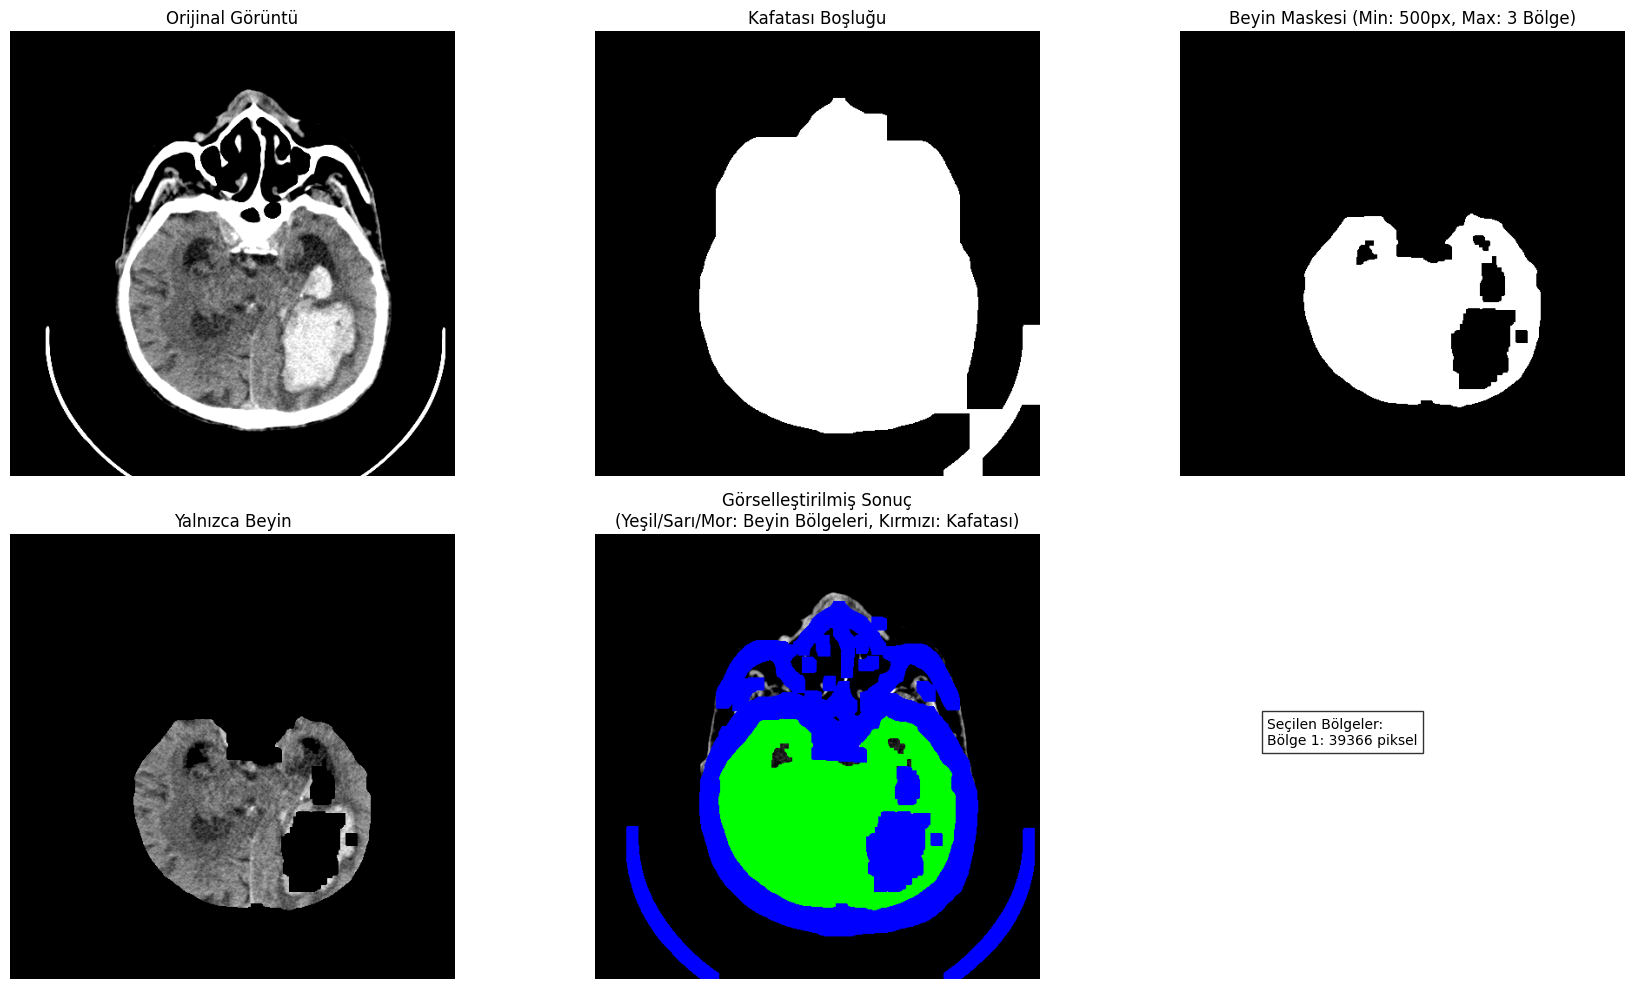

In [7]:
# Beyin olmayacak kadar küçük bölgeleri elemek ve max 3 bölgeyi almak için geliştirilmiş fonksiyon
def segment_brain_inside_skull(image_path, skull_threshold=230, brain_threshold=50, max_regions=3, min_region_size=500):
    # Görüntüyü yükle
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Hata: {image_path} yüklenemedi!")
        return None, None, None, None, None

    # 1. Kafatası konturu belirleme
    # Önce görüntüyü yumuşatma
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Kafatasının yüksek yoğunluklu bölgelerini tespit et
    _, skull_thresh = cv2.threshold(blurred, skull_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle kafatasını kalınlaştır
    kernel = np.ones((5, 5), np.uint8)
    skull_dilated = cv2.dilate(skull_thresh, kernel, iterations=3)

    # 2. Kafatası konturunun içini doldur (kafatası boşluğunu elde et)
    # Önce büyük bir kontur elde etmek için morfolojik işlemlerle kapatma
    skull_closed = cv2.morphologyEx(skull_dilated, cv2.MORPH_CLOSE, kernel, iterations=10)

    # Kafatası boşluğunu içerecek şekilde tüm konturları bul
    contours, _ = cv2.findContours(skull_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Kafatası konturu için boş bir maske oluştur
    skull_cavity_mask = np.zeros_like(image)

    # En büyük konturu kafatası olarak varsay ve içini doldur
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(skull_cavity_mask, [largest_contour], 0, 255, -1)

    # 3. Beyin bölgesini tespit et
    # Kafatası içindeki bölgelere odaklan (kafatası olmayan bölgeyi al)
    non_skull = cv2.bitwise_not(skull_dilated)

    # Kafatası boşluğu VE kafatası olmayan bölge = sadece kafatası içindeki yumuşak doku
    inner_region = cv2.bitwise_and(skull_cavity_mask, non_skull)

    # Beyin dokusunu diğer yumuşak dokulardan ayırmak için eşikleme
    _, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=inner_region),
                                  brain_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle beyin bölgesini temizle
    brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=2)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)

    # 4. Büyük bağlantılı beyin bölgelerini seç
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(brain_mask, connectivity=8)

    # Sadece yeterince büyük (min_region_size'dan büyük) bölgeleri filtrele
    filtered_regions = []
    for i in range(1, num_labels):  # 0 indeksi arka plan olduğu için atla
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_region_size:
            filtered_regions.append((i, area))

    # Alan bazında büyükten küçüğe sırala
    filtered_regions.sort(key=lambda x: x[1], reverse=True)

    # En fazla max_regions sayıda bölgeyi seç
    selected_regions = filtered_regions[:max_regions]

    # Seçilen bölgelerin maskelerini hazırla
    final_brain_mask = np.zeros_like(brain_mask)

    # Seçilen bölgelerin maskelerini birleştir
    for label, _ in selected_regions:
        current_mask = (labels == label).astype(np.uint8) * 255
        final_brain_mask = cv2.bitwise_or(final_brain_mask, current_mask)

    # Beyin bölgesini çıkar
    brain_only = cv2.bitwise_and(image, image, mask=final_brain_mask)

    # Görselleştirme için renkli sonuç hazırla
    colored_result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Renkli görselleştirmede her bölgeyi farklı renkle işaretle
    colors = [(0, 255, 0), (0, 255, 255), (255, 0, 255)]  # Yeşil, Sarı, Mor

    for i, (label, _) in enumerate(selected_regions):
        if i < len(colors):  # En fazla renk sayısı kadar bölge renklendir
            region_mask = (labels == label).astype(bool)
            colored_result[region_mask] = colors[i]

    # Kafatasını kırmızı olarak işaretle
    colored_result[skull_dilated > 0] = [0, 0, 255]

    # Hem seçilen bölgeleri hem de beyin bölgelerinin boyut sıralamasını döndür
    return image, skull_cavity_mask, final_brain_mask, brain_only, colored_result, selected_regions

# Test et
image_path = 'data/BeyinInmeVerisi-Siniflandirma/1/10542.png'
min_region_size = 500  # Beyin olmayacak kadar küçük yapıları elemek için minimum piksel sayısı
results = segment_brain_inside_skull(image_path, skull_threshold=230, brain_threshold=40, max_regions=3, min_region_size=min_region_size)

if results is not None and len(results) >= 6:
    orig_img, skull_cavity, brain_mask, brain_only, colored_vis, selected_regions = results

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(orig_img, cmap='gray')
    plt.title('Orijinal Görüntü')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(skull_cavity, cmap='gray')
    plt.title('Kafatası Boşluğu')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(brain_mask, cmap='gray')
    plt.title(f'Beyin Maskesi (Min: {min_region_size}px, Max: 3 Bölge)')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(brain_only, cmap='gray')
    plt.title('Yalnızca Beyin')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(colored_vis)
    plt.title('Görselleştirilmiş Sonuç\n(Yeşil/Sarı/Mor: Beyin Bölgeleri, Kırmızı: Kafatası)')
    plt.axis('off')

    # Seçilen bölgeler hakkında bilgi ekle
    region_info = "\n".join([f"Bölge {i+1}: {area} piksel" for i, (_, area) in enumerate(selected_regions)])
    plt.figtext(0.75, 0.25, f"Seçilen Bölgeler:\n{region_info}",
               bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# Boşlukları Doldur

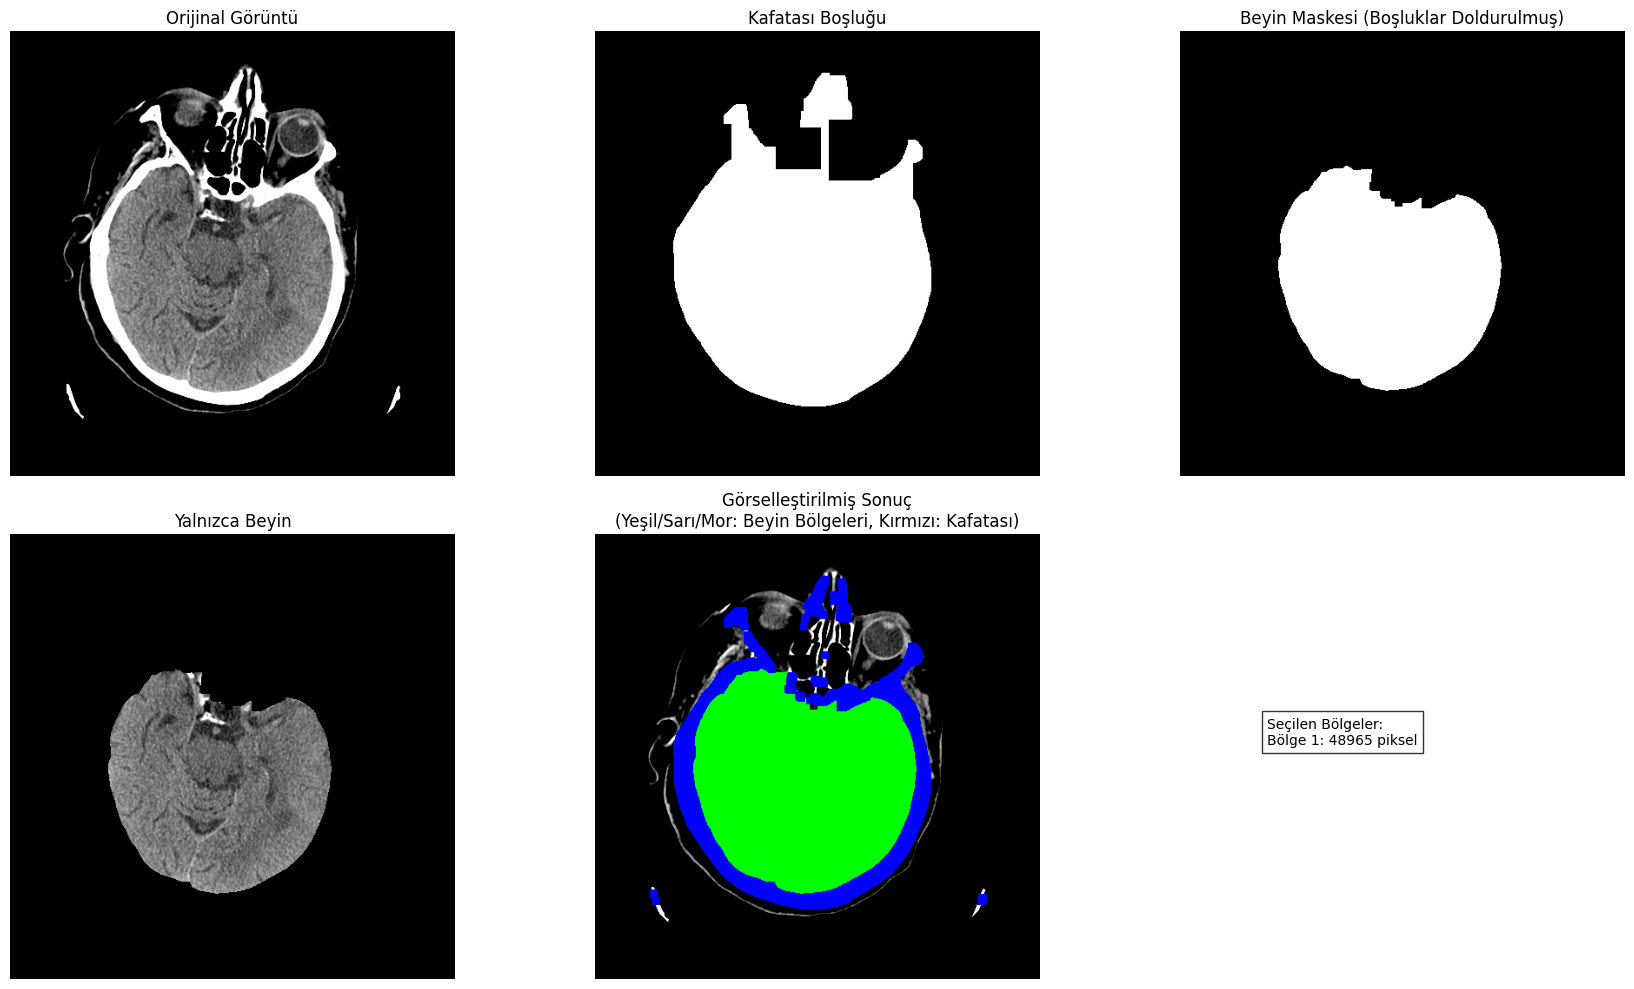

In [277]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Beyin segmentasyonu yapan ve segmentasyon bölgelerindeki boşlukları dolduran fonksiyon
def segment_brain_inside_skull(image_path, skull_threshold=254, brain_threshold=10, max_regions=3, min_region_size=1800):
    # Görüntüyü yükle
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Hata: {image_path} yüklenemedi!")
        return None, None, None, None, None, None

    # 1. Kafatası konturu belirleme
    # Önce görüntüyü yumuşatma
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Kafatasının yüksek yoğunluklu bölgelerini tespit et
    _, skull_thresh = cv2.threshold(blurred, skull_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle kafatasını kalınlaştır
    kernel = np.ones((5, 5), np.uint8)
    skull_dilated = cv2.dilate(skull_thresh, kernel, iterations=2)

    # 2. Kafatası konturunun içini doldur (kafatası boşluğunu elde et)
    # Önce büyük bir kontur elde etmek için morfolojik işlemlerle kapatma
    skull_closed = cv2.morphologyEx(skull_dilated, cv2.MORPH_CLOSE, kernel, iterations=10)

    # Kafatası boşluğunu içerecek şekilde tüm konturları bul
    contours, _ = cv2.findContours(skull_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Kafatası konturu için boş bir maske oluştur
    skull_cavity_mask = np.zeros_like(image)

    # En büyük konturu kafatası olarak varsay ve içini doldur
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        cv2.drawContours(skull_cavity_mask, [largest_contour], 0, 255, -1)

    # 3. Beyin bölgesini tespit et
    # Kafatası içindeki bölgelere odaklan (kafatası olmayan bölgeyi al)
    non_skull = cv2.bitwise_not(skull_dilated)

    # Kafatası boşluğu VE kafatası olmayan bölge = sadece kafatası içindeki yumuşak doku
    inner_region = cv2.bitwise_and(skull_cavity_mask, non_skull)

    # Beyin dokusunu diğer yumuşak dokulardan ayırmak için eşikleme
    _, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=inner_region),
                                  brain_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle beyin bölgesini temizle
    brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=2)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)

    # 4. Büyük bağlantılı beyin bölgelerini seç
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(brain_mask, connectivity=8)

    # Sadece yeterince büyük (min_region_size'dan büyük) bölgeleri filtrele
    filtered_regions = []
    for i in range(1, num_labels):  # 0 indeksi arka plan olduğu için atla
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_region_size:
            filtered_regions.append((i, area))

    # Alan bazında büyükten küçüğe sırala
    filtered_regions.sort(key=lambda x: x[1], reverse=True)

    # En fazla max_regions sayıda bölgeyi seç
    selected_regions = filtered_regions[:max_regions]

    # Seçilen bölgelerin maskelerini hazırla
    final_brain_mask = np.zeros_like(brain_mask)

    # Her bir seçilen bölgeyi ayrı ayrı işle
    for label, _ in selected_regions:
        # Bölgeyi maskele
        current_mask = (labels == label).astype(np.uint8) * 255

        # Bölgedeki boşlukları doldur
        # Konturları bul (dış kontur ve iç boşluklar)
        contours, hierarchy = cv2.findContours(current_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

        # Tüm konturları (dış kontur ve tüm iç boşluklar) doldur
        filled_mask = np.zeros_like(current_mask)
        for i, contour in enumerate(contours):
            # hierarchy[0, i, 3] == -1 ise bu dış kontur demektir
            # Tüm konturları doldurmak istediğimiz için bu kontrolü kullanmıyoruz
            cv2.drawContours(filled_mask, [contour], 0, 255, -1)

        # Doldurulmuş maske ile final maskeyi güncelle
        final_brain_mask = cv2.bitwise_or(final_brain_mask, filled_mask)

    # Boşlukları doldurulmuş maskeyi bir daha işleyelim
    # Alternatif bir yaklaşımla, morfolojik kapatma (closing) işlemi de uygulayalım
    final_brain_mask = cv2.morphologyEx(final_brain_mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)

    # Beyin bölgesini çıkar
    brain_only = cv2.bitwise_and(image, image, mask=final_brain_mask)

    # Görselleştirme için renkli sonuç hazırla
    colored_result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Renkli görselleştirmede her bölgeyi farklı renkle işaretle
    colors = [(0, 255, 0), (0, 255, 255), (255, 0, 255)]  # Yeşil, Sarı, Mor

    # Farklı renklerle segmentasyon görselleştirmesi için tekrar bağlantılı bileşen analizi yap
    # (boşluklar doldurulduktan sonra)
    num_labels_filled, labels_filled = cv2.connectedComponents(final_brain_mask)

    # Her bir seçilen bölge için farklı renk kullan
    for i, (original_label, _) in enumerate(selected_regions):
        if i < len(colors):
            # Doldurulmuş bölgelerdeki yeni etiketi bul
            # En çok örtüşen bölgeyi bul
            max_overlap = 0
            max_overlap_label = 0

            for j in range(1, num_labels_filled):
                # Orijinal maske
                original_mask = (labels == original_label)
                # Yeni maske
                new_mask = (labels_filled == j)
                # Örtüşen pikseller
                overlap = np.sum(np.logical_and(original_mask, new_mask))

                if overlap > max_overlap:
                    max_overlap = overlap
                    max_overlap_label = j

            # En çok örtüşen bölgeyi renklendir
            if max_overlap_label > 0:
                region_mask = (labels_filled == max_overlap_label)
                colored_result[region_mask] = colors[i]

    # Kafatasını kırmızı olarak işaretle
    colored_result[skull_dilated > 0] = [0, 0, 255]

    # Hem seçilen bölgeleri hem de beyin bölgelerinin boyut sıralamasını döndür
    return image, skull_cavity_mask, final_brain_mask, brain_only, colored_result, selected_regions

# Test et
image_path = 'data/BeyinInmeVerisi-Siniflandirma/1/10181.png'
results = segment_brain_inside_skull(image_path, skull_threshold=254, brain_threshold=40, max_regions=3, min_region_size=1800)

if results is not None and len(results) >= 6:
    orig_img, skull_cavity, brain_mask, brain_only, colored_vis, selected_regions = results

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(orig_img, cmap='gray')
    plt.title('Orijinal Görüntü')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(skull_cavity, cmap='gray')
    plt.title('Kafatası Boşluğu')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(brain_mask, cmap='gray')
    plt.title(f'Beyin Maskesi (Boşluklar Doldurulmuş)')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(brain_only, cmap='gray')
    plt.title('Yalnızca Beyin')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(colored_vis)
    plt.title('Görselleştirilmiş Sonuç\n(Yeşil/Sarı/Mor: Beyin Bölgeleri, Kırmızı: Kafatası)')
    plt.axis('off')

    # Seçilen bölgeler hakkında bilgi ekle
    region_info = "\n".join([f"Bölge {i+1}: {area} piksel" for i, (_, area) in enumerate(selected_regions)])
    plt.figtext(0.75, 0.25, f"Seçilen Bölgeler:\n{region_info}",
               bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# İnmeli bölge kafatasına bitişik ise

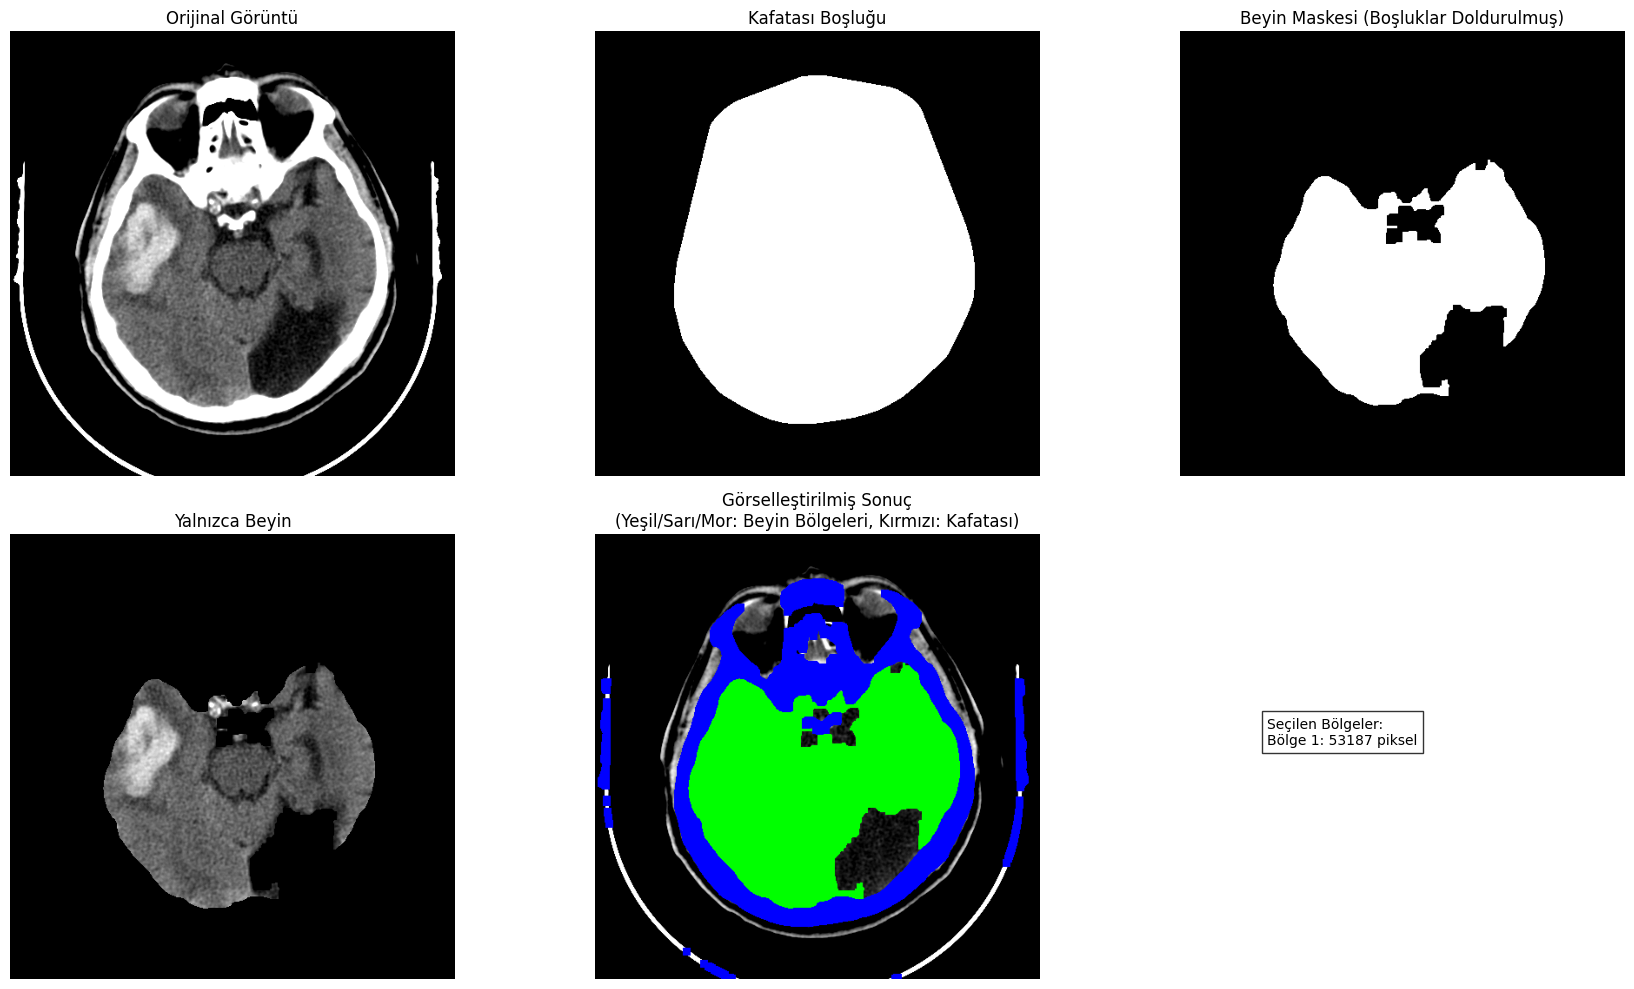

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Beyin segmentasyonu yapan ve segmentasyon bölgelerindeki boşlukları dolduran fonksiyon
def segment_brain_inside_skull(image_path, skull_threshold=254, brain_threshold=10, max_regions=3, min_region_size=1800):
    # Görüntüyü yükle
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        print(f"Hata: {image_path} yüklenemedi!")
        return None, None, None, None, None, None

    # 1. Kafatası konturu belirleme
    # Önce görüntüyü yumuşatma
    blurred = cv2.GaussianBlur(image, (5, 5), 0)

    # Kafatasının yüksek yoğunluklu bölgelerini tespit et
    _, skull_thresh = cv2.threshold(blurred, skull_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle kafatasını kalınlaştır
    kernel = np.ones((5, 5), np.uint8)
    skull_dilated = cv2.dilate(skull_thresh, kernel, iterations=2)

    # 2. Kafatası konturunun içini doldur (kafatası boşluğunu elde et)
    # Önce büyük bir kontur elde etmek için morfolojik işlemlerle kapatma
    skull_closed = cv2.morphologyEx(skull_dilated, cv2.MORPH_CLOSE, kernel, iterations=10)

    # Kafatası boşluğunu içerecek şekilde tüm konturları bul
    contours, _ = cv2.findContours(skull_closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Kafatası konturu için boş bir maske oluştur
    skull_cavity_mask = np.zeros_like(image)

    # En büyük konturu kafatası olarak varsay ve içini doldur
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        # Convex Hull ile konturu tamamla
        hull = cv2.convexHull(largest_contour)
        cv2.drawContours(skull_cavity_mask, [hull], 0, 255, -1)

    # 3. Beyin bölgesini tespit et
    # Kafatası içindeki bölgelere odaklan (kafatası olmayan bölgeyi al)
    non_skull = cv2.bitwise_not(skull_dilated)

    # Kafatası boşluğu VE kafatası olmayan bölge = sadece kafatası içindeki yumuşak doku
    inner_region = cv2.bitwise_and(skull_cavity_mask, non_skull)

    # Beyin dokusunu diğer yumuşak dokulardan ayırmak için eşikleme
    _, brain_thresh = cv2.threshold(cv2.bitwise_and(blurred, blurred, mask=inner_region),
                                  brain_threshold, 255, cv2.THRESH_BINARY)

    # Morfolojik işlemlerle beyin bölgesini temizle
    brain_mask = cv2.morphologyEx(brain_thresh, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=2)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_OPEN, np.ones((3, 3), np.uint8), iterations=1)

    # 4. Büyük bağlantılı beyin bölgelerini seç
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(brain_mask, connectivity=8)

    # Sadece yeterince büyük (min_region_size'dan büyük) bölgeleri filtrele
    filtered_regions = []
    for i in range(1, num_labels):  # 0 indeksi arka plan olduğu için atla
        area = stats[i, cv2.CC_STAT_AREA]
        if area > min_region_size:
            filtered_regions.append((i, area))

    # Alan bazında büyükten küçüğe sırala
    filtered_regions.sort(key=lambda x: x[1], reverse=True)

    # En fazla max_regions sayıda bölgeyi seç
    selected_regions = filtered_regions[:max_regions]

    # Seçilen bölgelerin maskelerini hazırla
    final_brain_mask = np.zeros_like(brain_mask)

    # Her bir seçilen bölgeyi ayrı ayrı işle
    for label, _ in selected_regions:
        # Bölgeyi maskele
        current_mask = (labels == label).astype(np.uint8) * 255

        # Bölgedeki boşlukları doldur
        # Konturları bul (dış kontur ve iç boşluklar)
        contours, hierarchy = cv2.findContours(current_mask, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)

        # Tüm konturları (dış kontur ve tüm iç boşluklar) doldur
        filled_mask = np.zeros_like(current_mask)
        for i, contour in enumerate(contours):
            # hierarchy[0, i, 3] == -1 ise bu dış kontur demektir
            # Tüm konturları doldurmak istediğimiz için bu kontrolü kullanmıyoruz
            cv2.drawContours(filled_mask, [contour], 0, 255, -1)

        # Doldurulmuş maske ile final maskeyi güncelle
        final_brain_mask = cv2.bitwise_or(final_brain_mask, filled_mask)

    # Boşlukları doldurulmuş maskeyi bir daha işleyelim
    # Alternatif bir yaklaşımla, morfolojik kapatma (closing) işlemi de uygulayalım
    final_brain_mask = cv2.morphologyEx(final_brain_mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8), iterations=2)

    # Beyin bölgesini çıkar
    brain_only = cv2.bitwise_and(image, image, mask=final_brain_mask)

    # Görselleştirme için renkli sonuç hazırla
    colored_result = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    # Renkli görselleştirmede her bölgeyi farklı renkle işaretle
    colors = [(0, 255, 0), (0, 255, 255), (255, 0, 255)]  # Yeşil, Sarı, Mor

    # Farklı renklerle segmentasyon görselleştirmesi için tekrar bağlantılı bileşen analizi yap
    # (boşluklar doldurulduktan sonra)
    num_labels_filled, labels_filled = cv2.connectedComponents(final_brain_mask)

    # Her bir seçilen bölge için farklı renk kullan
    for i, (original_label, _) in enumerate(selected_regions):
        if i < len(colors):
            # Doldurulmuş bölgelerdeki yeni etiketi bul
            # En çok örtüşen bölgeyi bul
            max_overlap = 0
            max_overlap_label = 0

            for j in range(1, num_labels_filled):
                # Orijinal maske
                original_mask = (labels == original_label)
                # Yeni maske
                new_mask = (labels_filled == j)
                # Örtüşen pikseller
                overlap = np.sum(np.logical_and(original_mask, new_mask))

                if overlap > max_overlap:
                    max_overlap = overlap
                    max_overlap_label = j

            # En çok örtüşen bölgeyi renklendir
            if max_overlap_label > 0:
                region_mask = (labels_filled == max_overlap_label)
                colored_result[region_mask] = colors[i]

    # Kafatasını kırmızı olarak işaretle
    colored_result[skull_dilated > 0] = [0, 0, 255]

    # Hem seçilen bölgeleri hem de beyin bölgelerinin boyut sıralamasını döndür
    return image, skull_cavity_mask, final_brain_mask, brain_only, colored_result, selected_regions

# Test et
image_path = 'data/BeyinInmeVerisi-Siniflandirma/1/13336.png'
results = segment_brain_inside_skull(image_path, skull_threshold=254, brain_threshold=30, max_regions=3, min_region_size=1800)

if results is not None and len(results) >= 6:
    orig_img, skull_cavity, brain_mask, brain_only, colored_vis, selected_regions = results

    plt.figure(figsize=(18, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(orig_img, cmap='gray')
    plt.title('Orijinal Görüntü')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(skull_cavity, cmap='gray')
    plt.title('Kafatası Boşluğu')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(brain_mask, cmap='gray')
    plt.title(f'Beyin Maskesi (Boşluklar Doldurulmuş)')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(brain_only, cmap='gray')
    plt.title('Yalnızca Beyin')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(colored_vis)
    plt.title('Görselleştirilmiş Sonuç\n(Yeşil/Sarı/Mor: Beyin Bölgeleri, Kırmızı: Kafatası)')
    plt.axis('off')

    # Seçilen bölgeler hakkında bilgi ekle
    region_info = "\n".join([f"Bölge {i+1}: {area} piksel" for i, (_, area) in enumerate(selected_regions)])
    plt.figtext(0.75, 0.25, f"Seçilen Bölgeler:\n{region_info}",
               bbox=dict(facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.show()

# En Sonki Elde Edilen Fonksiyonu Test Et

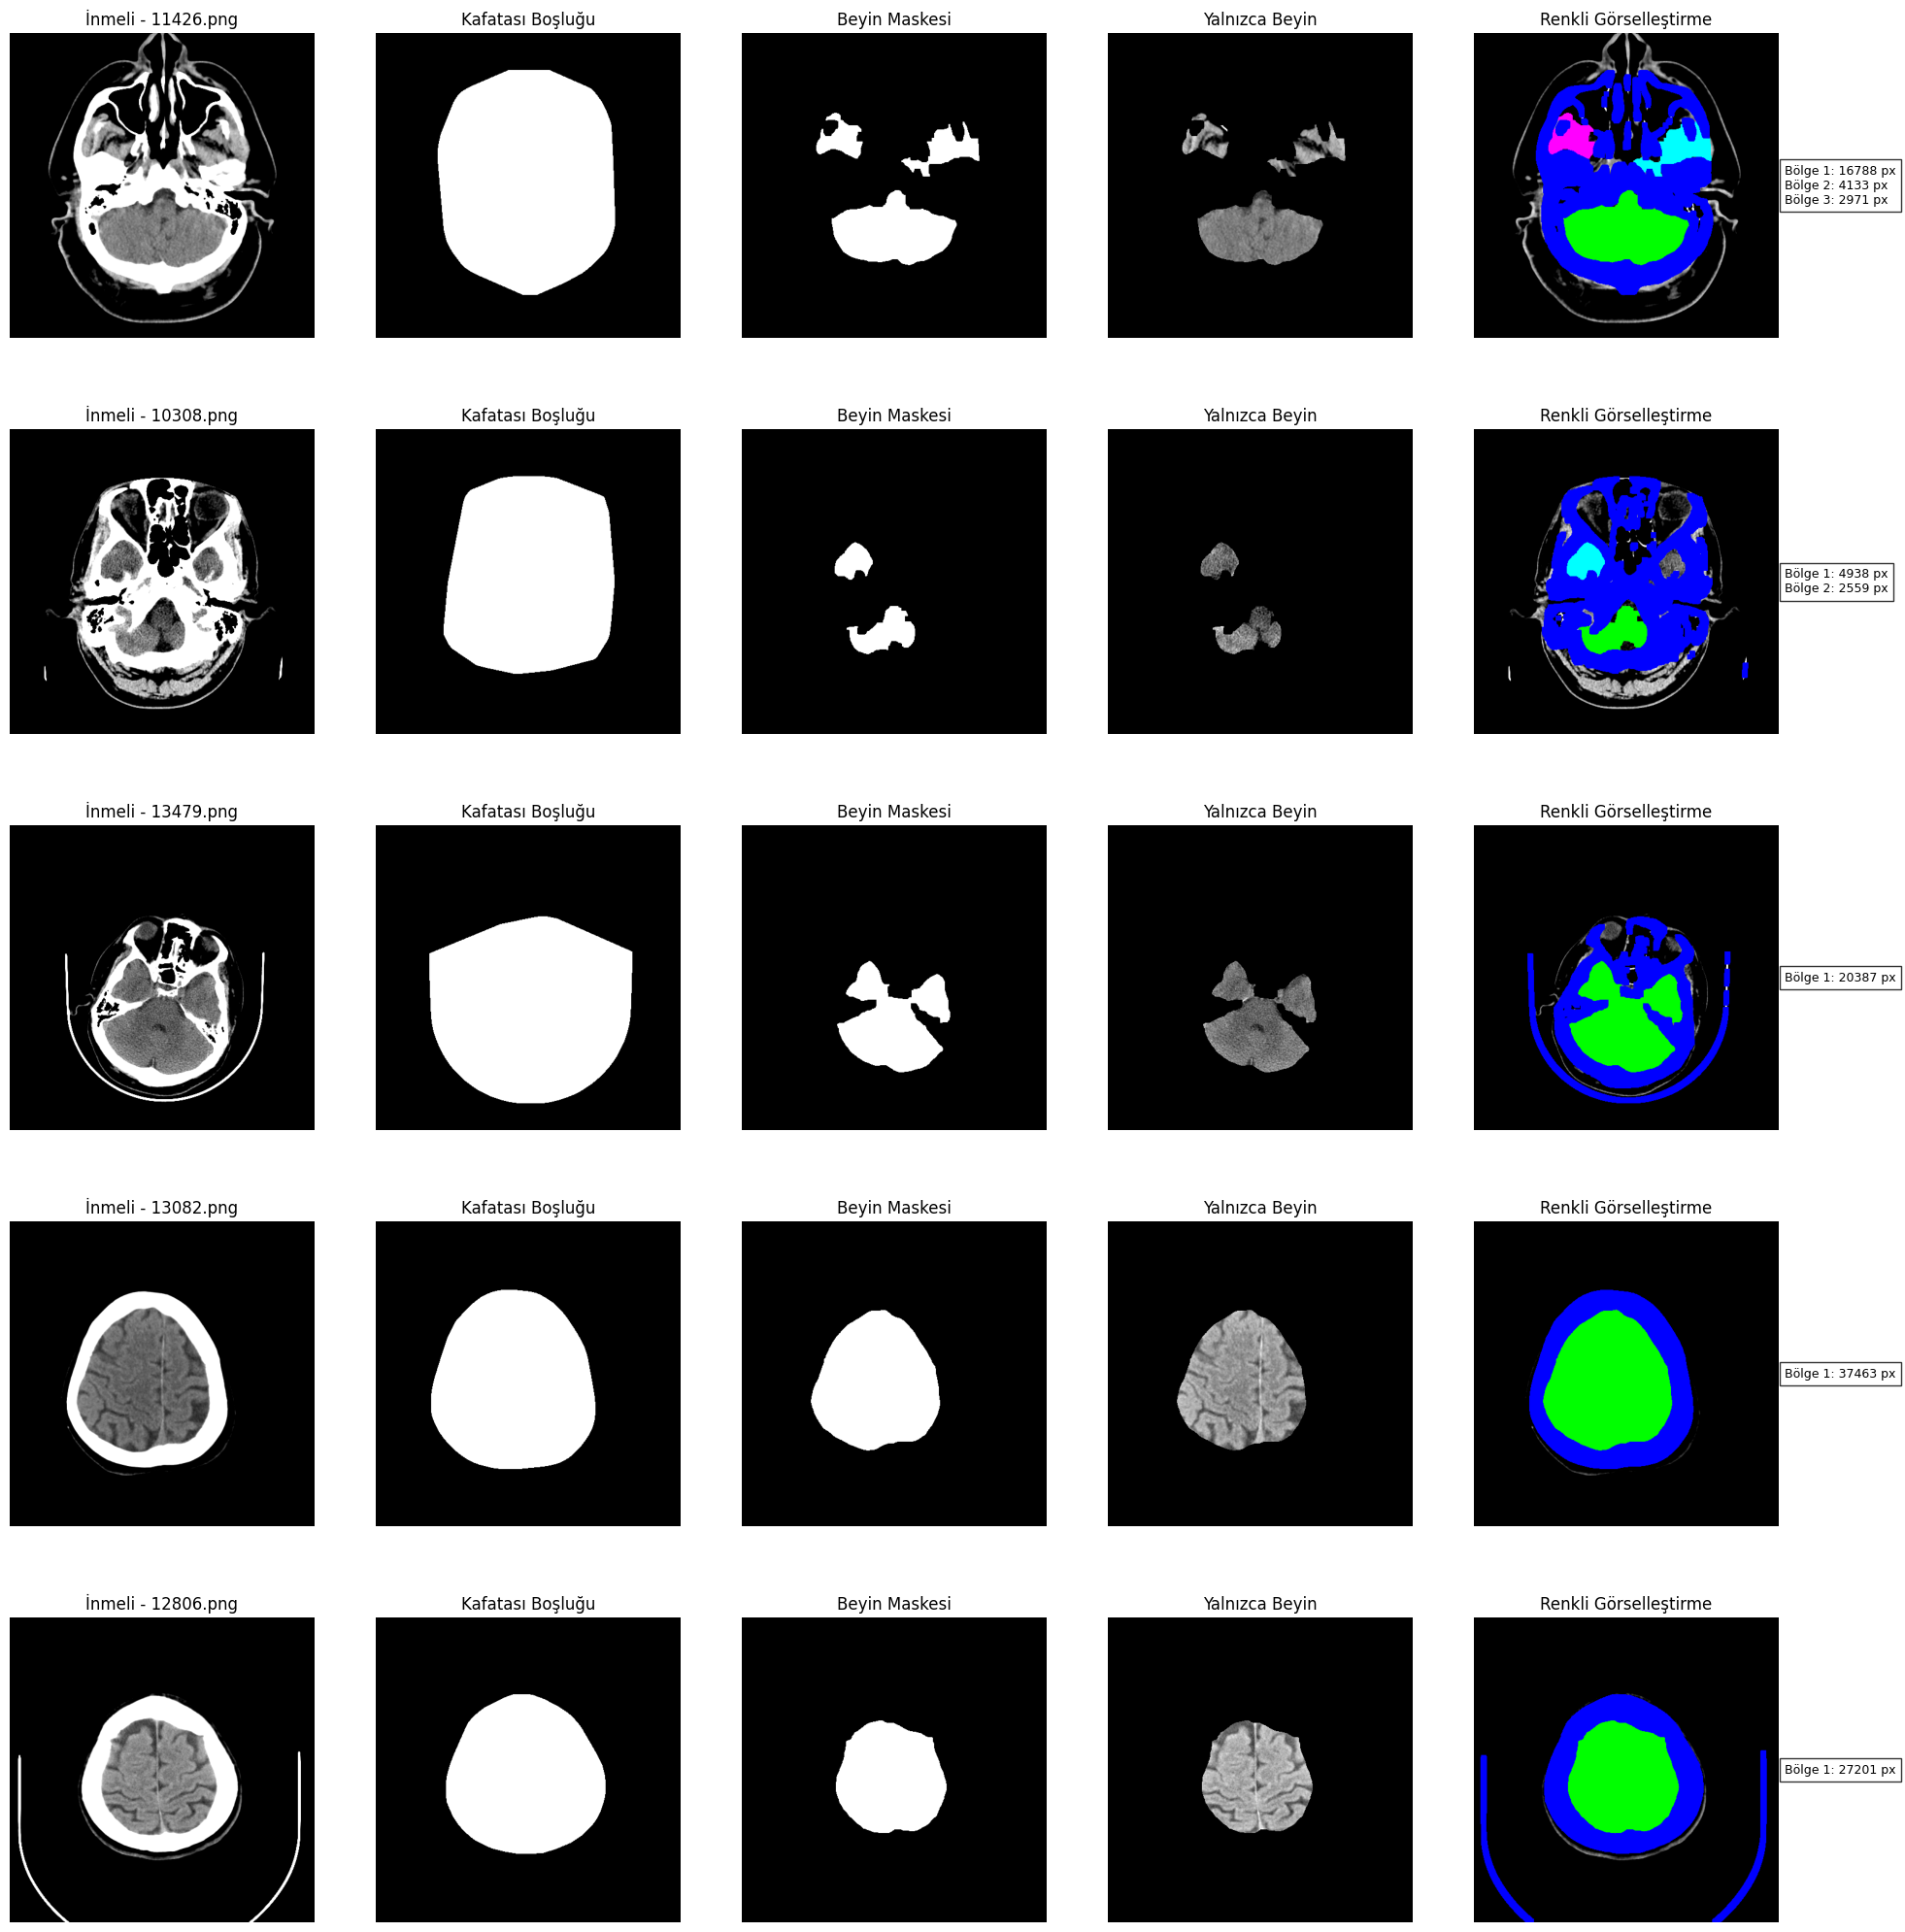

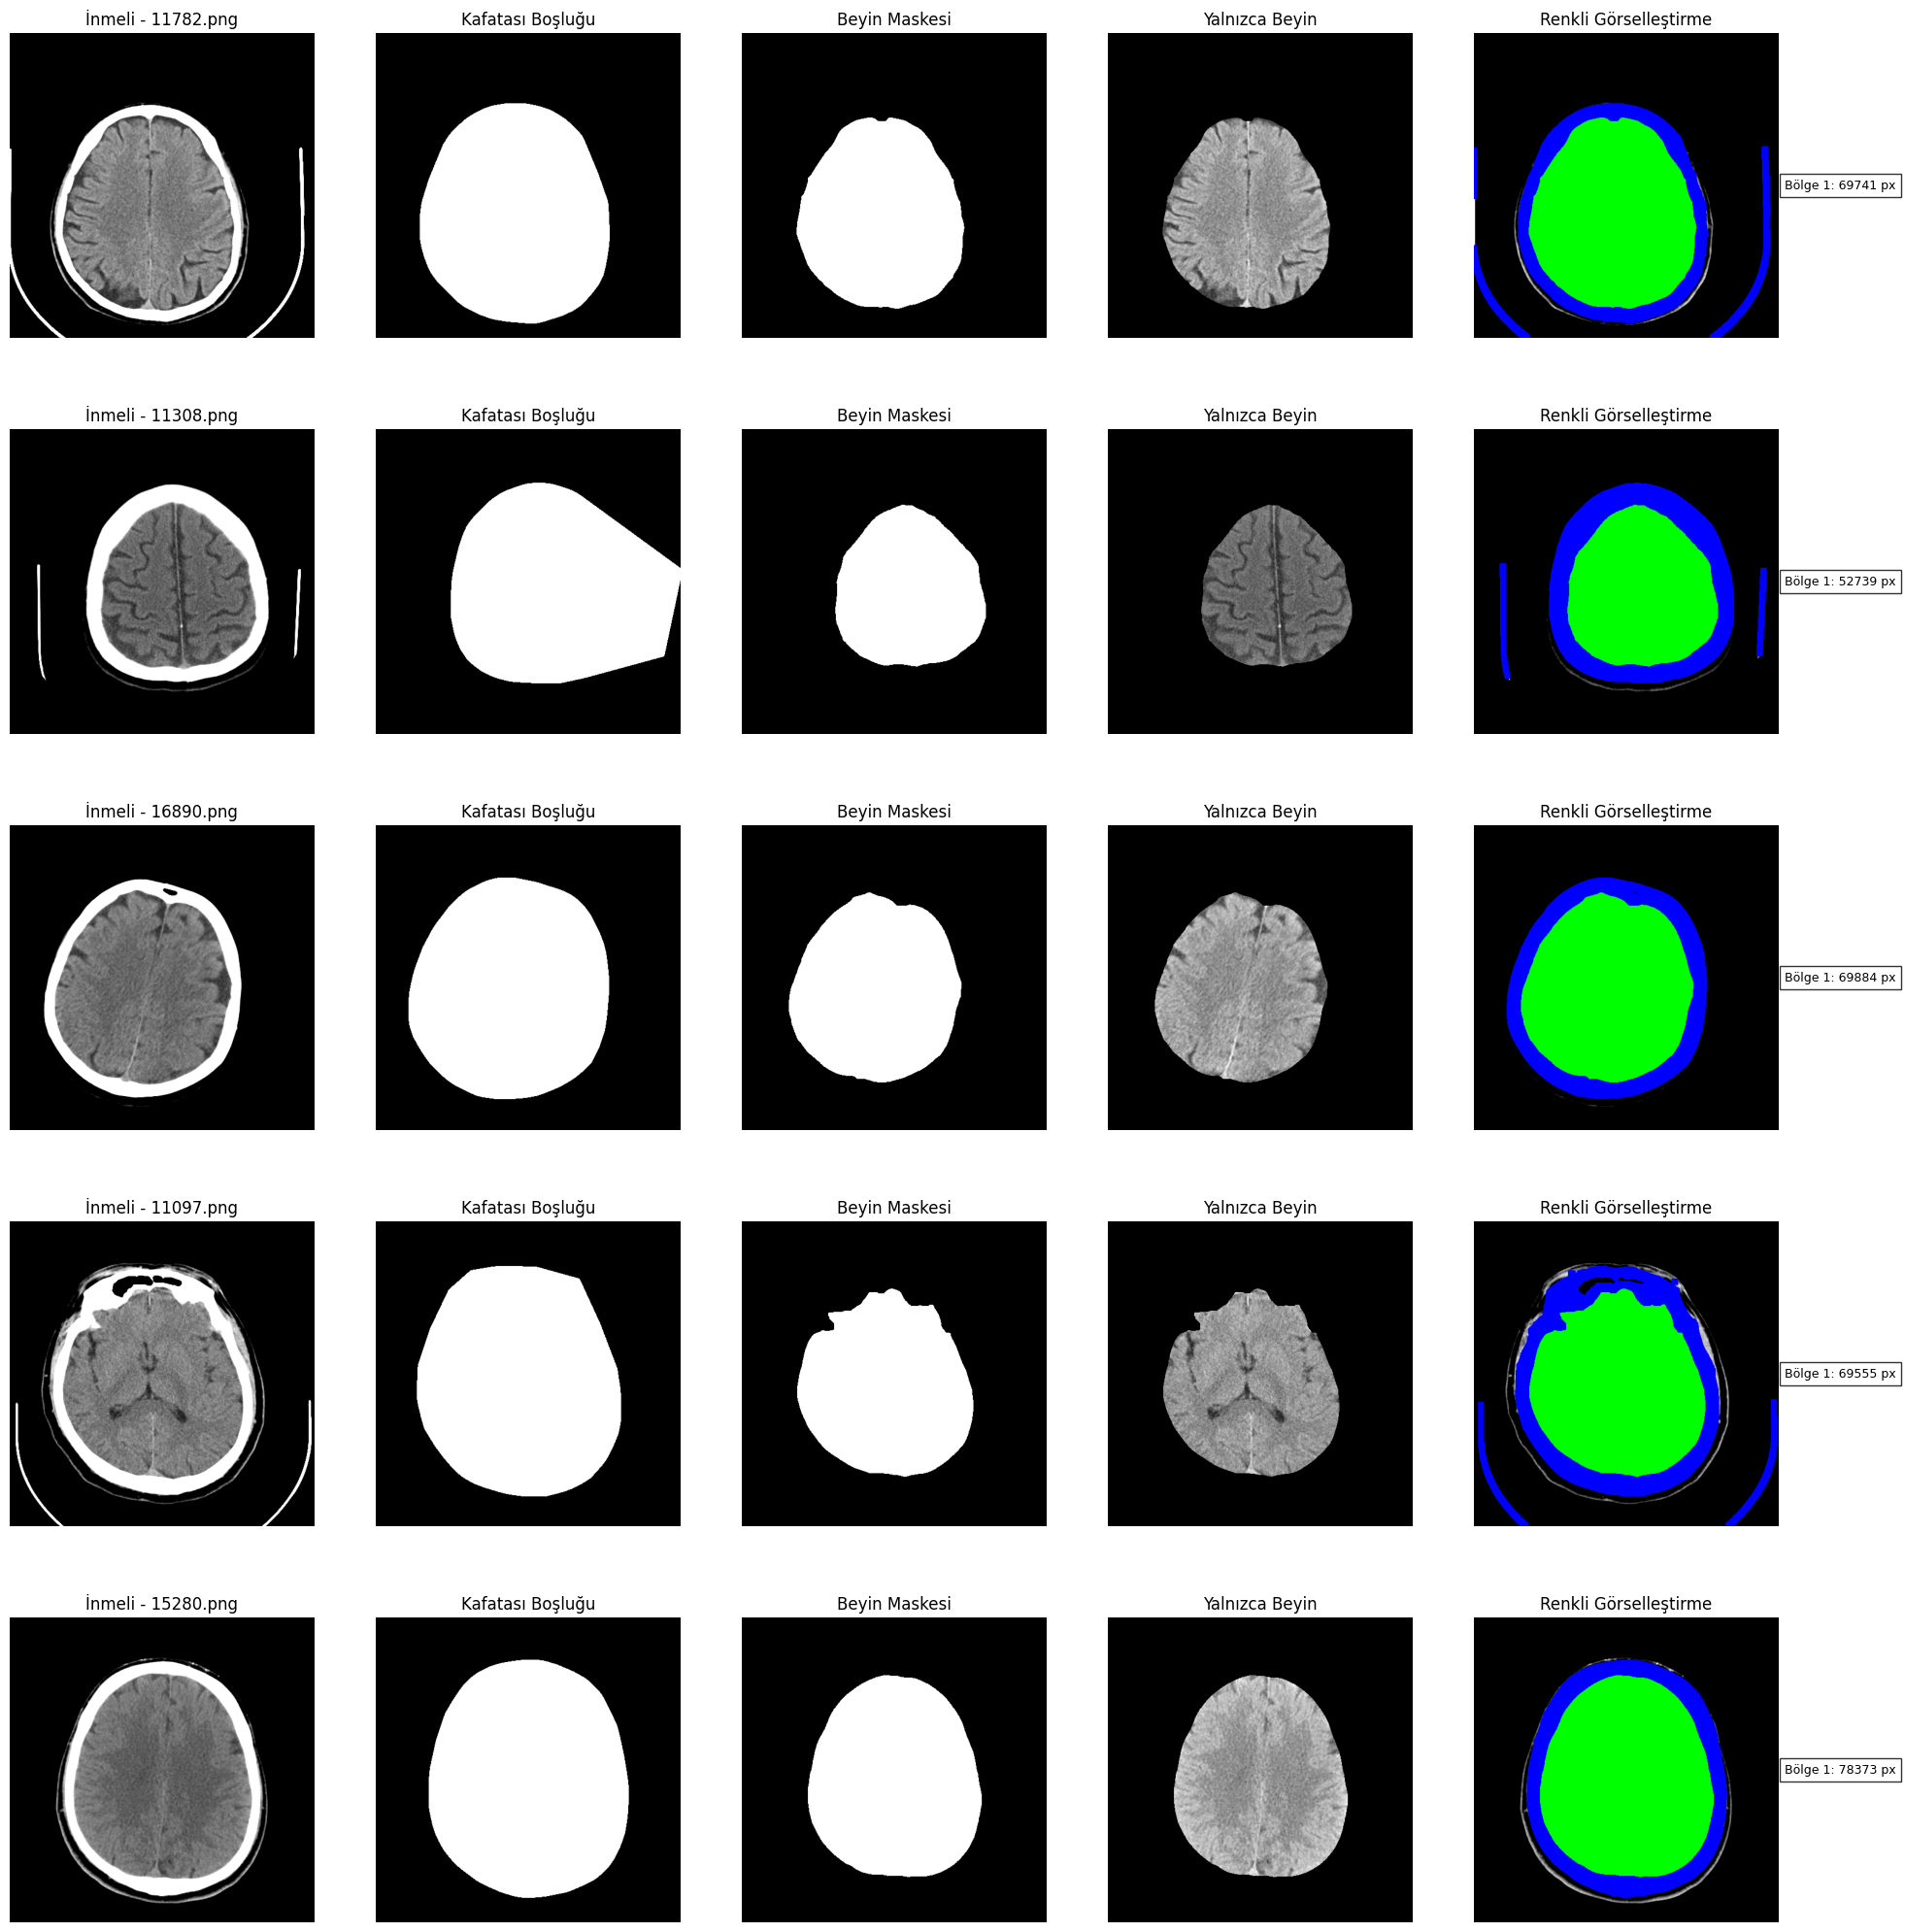

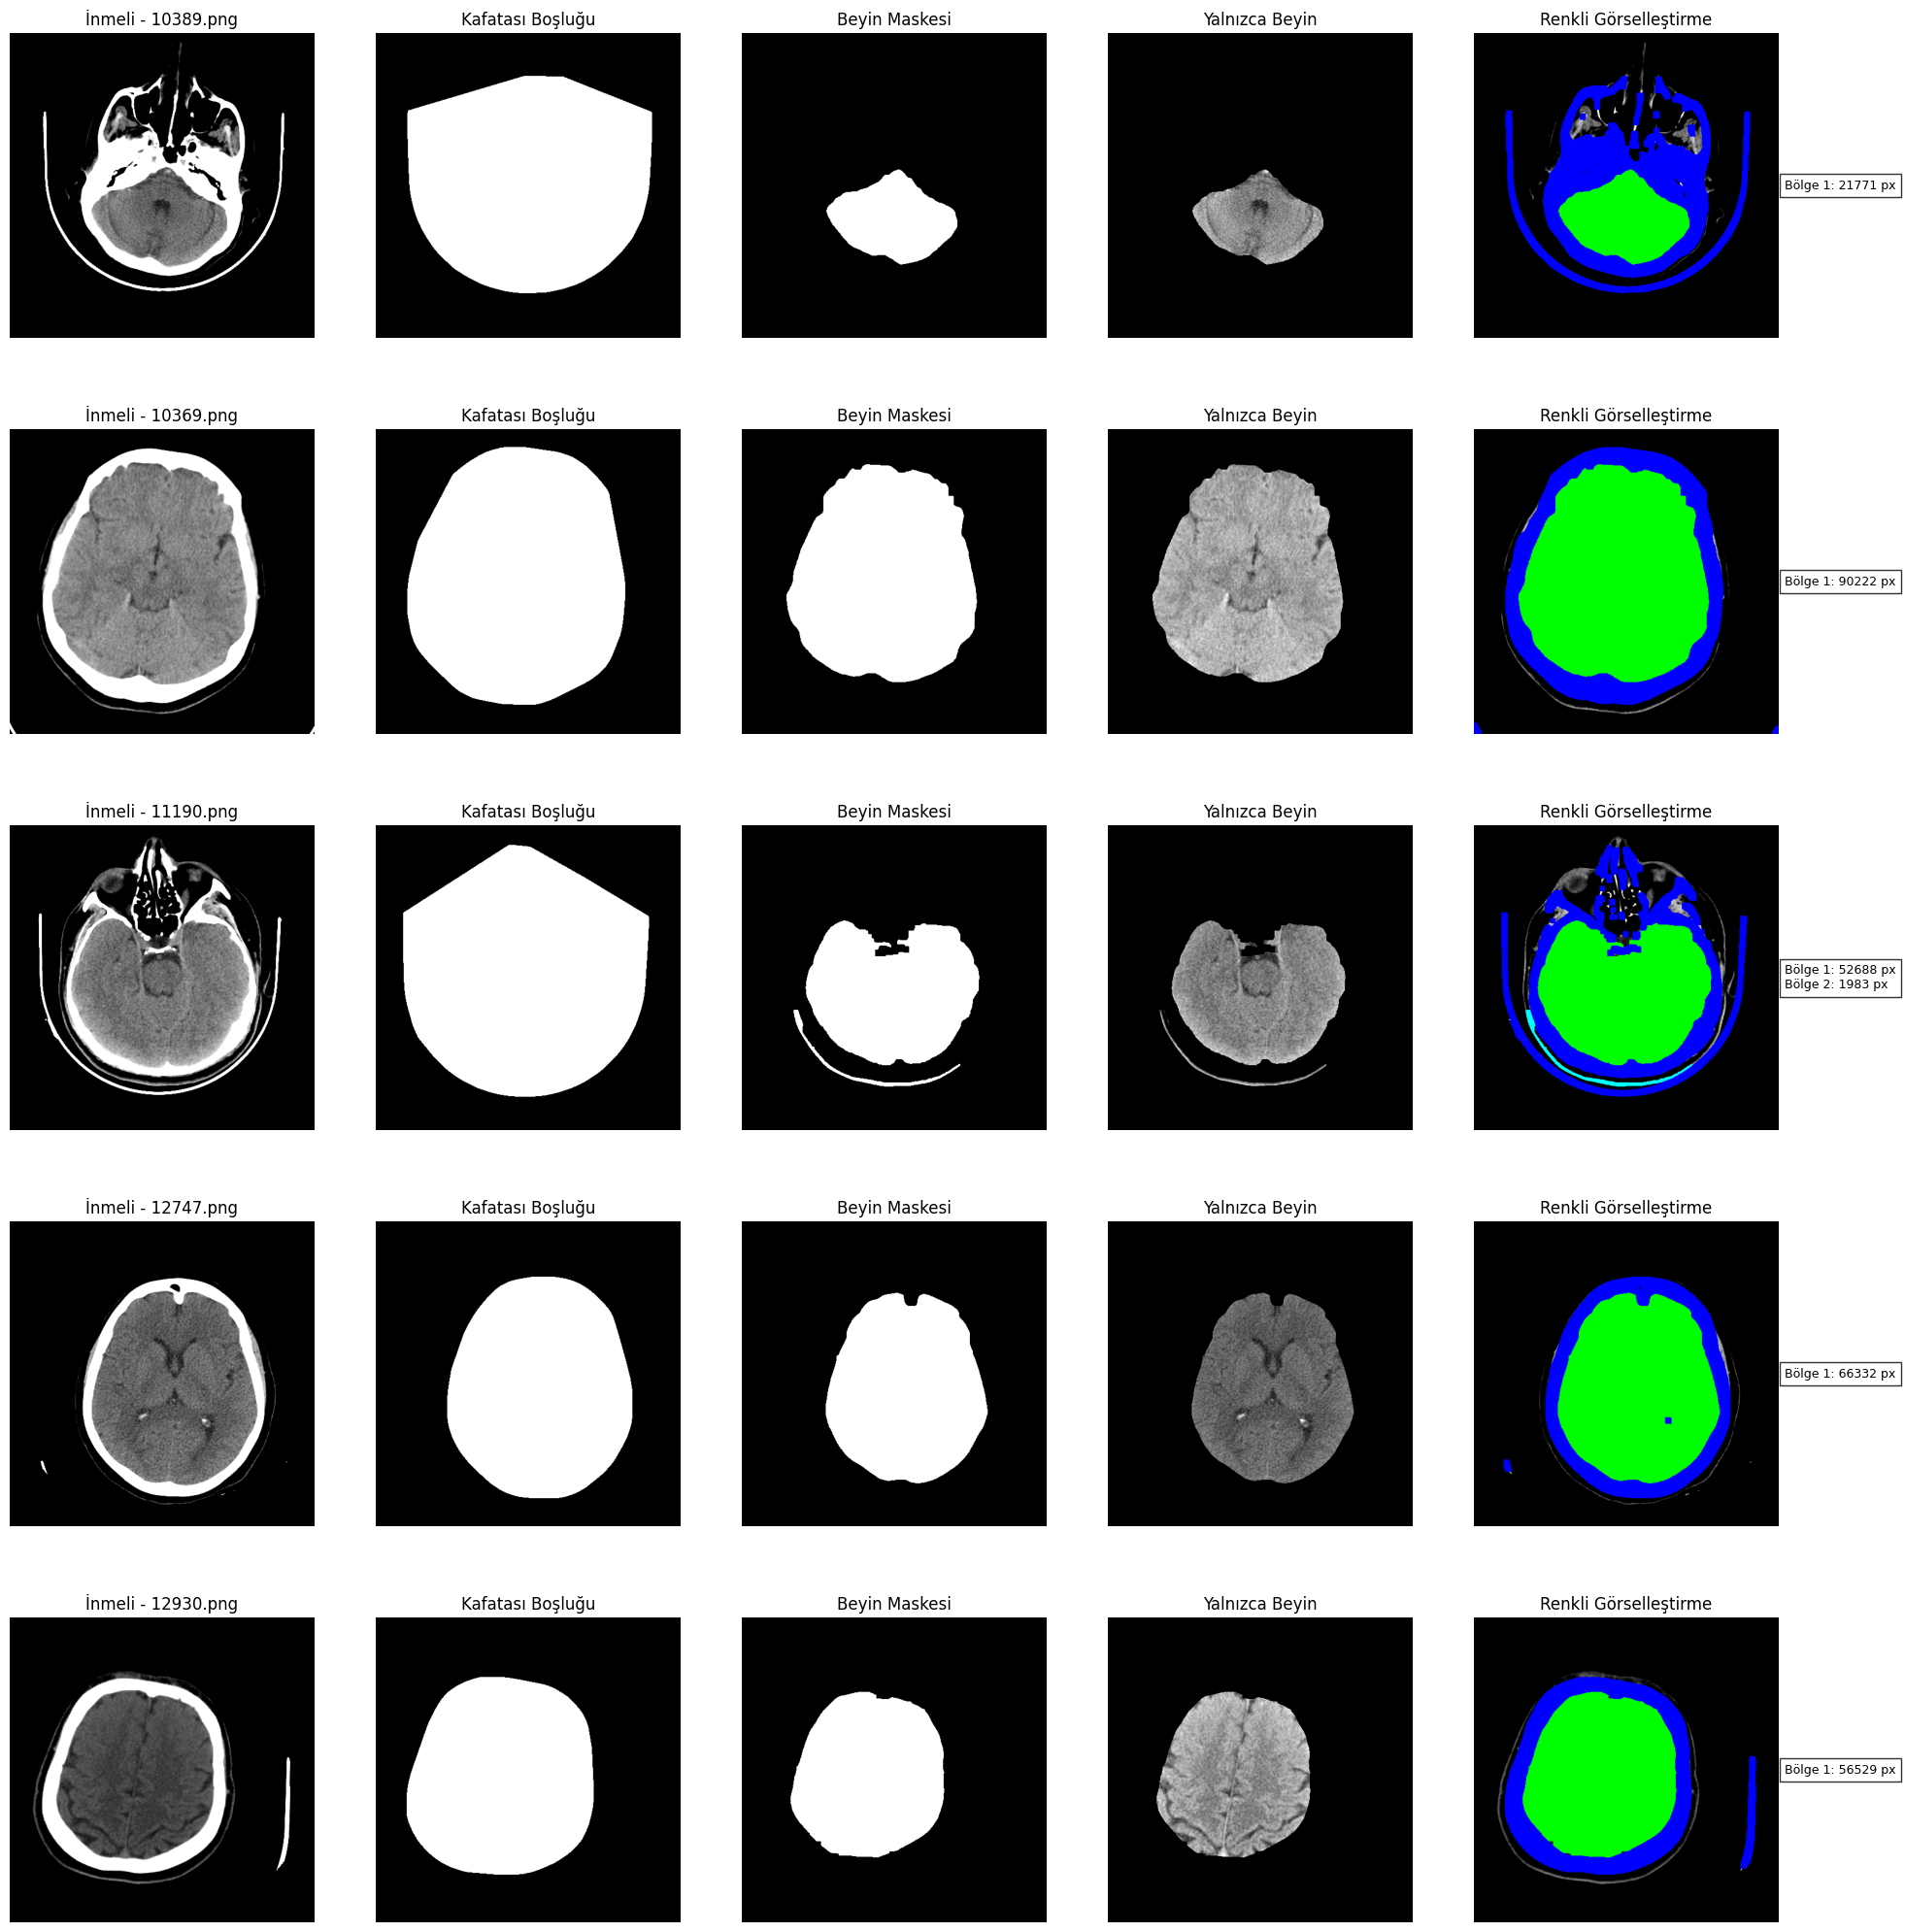

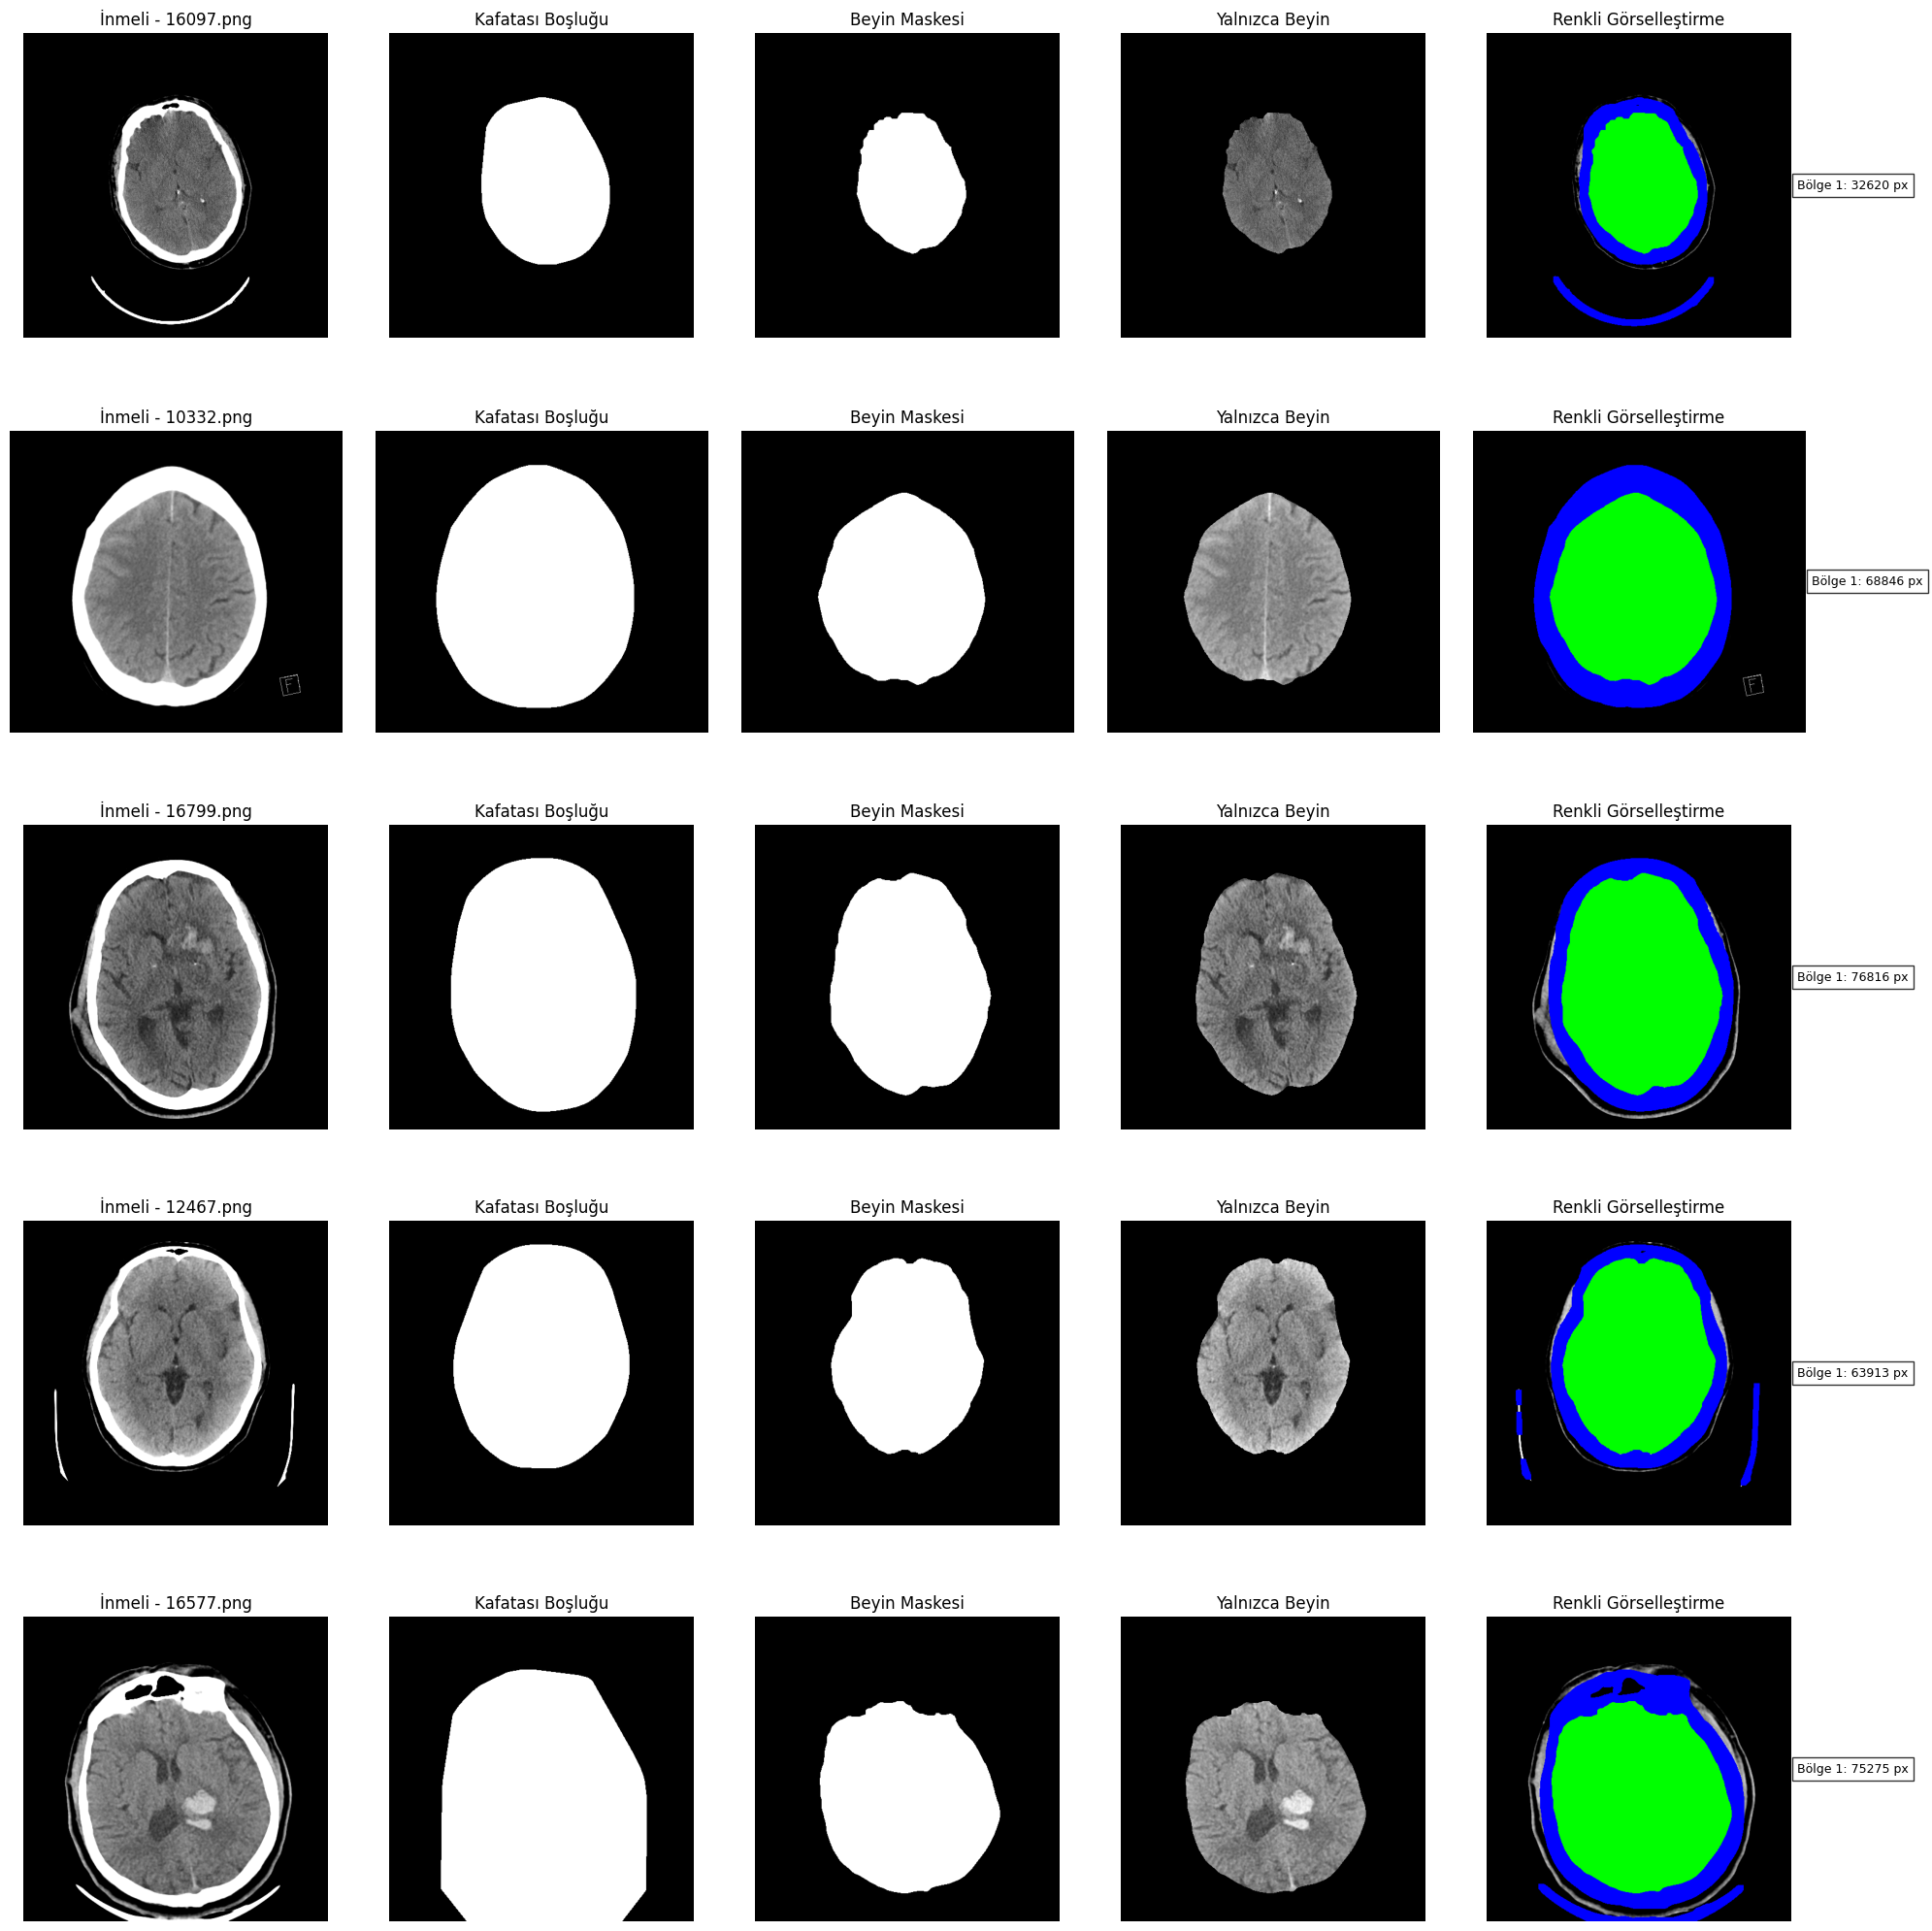

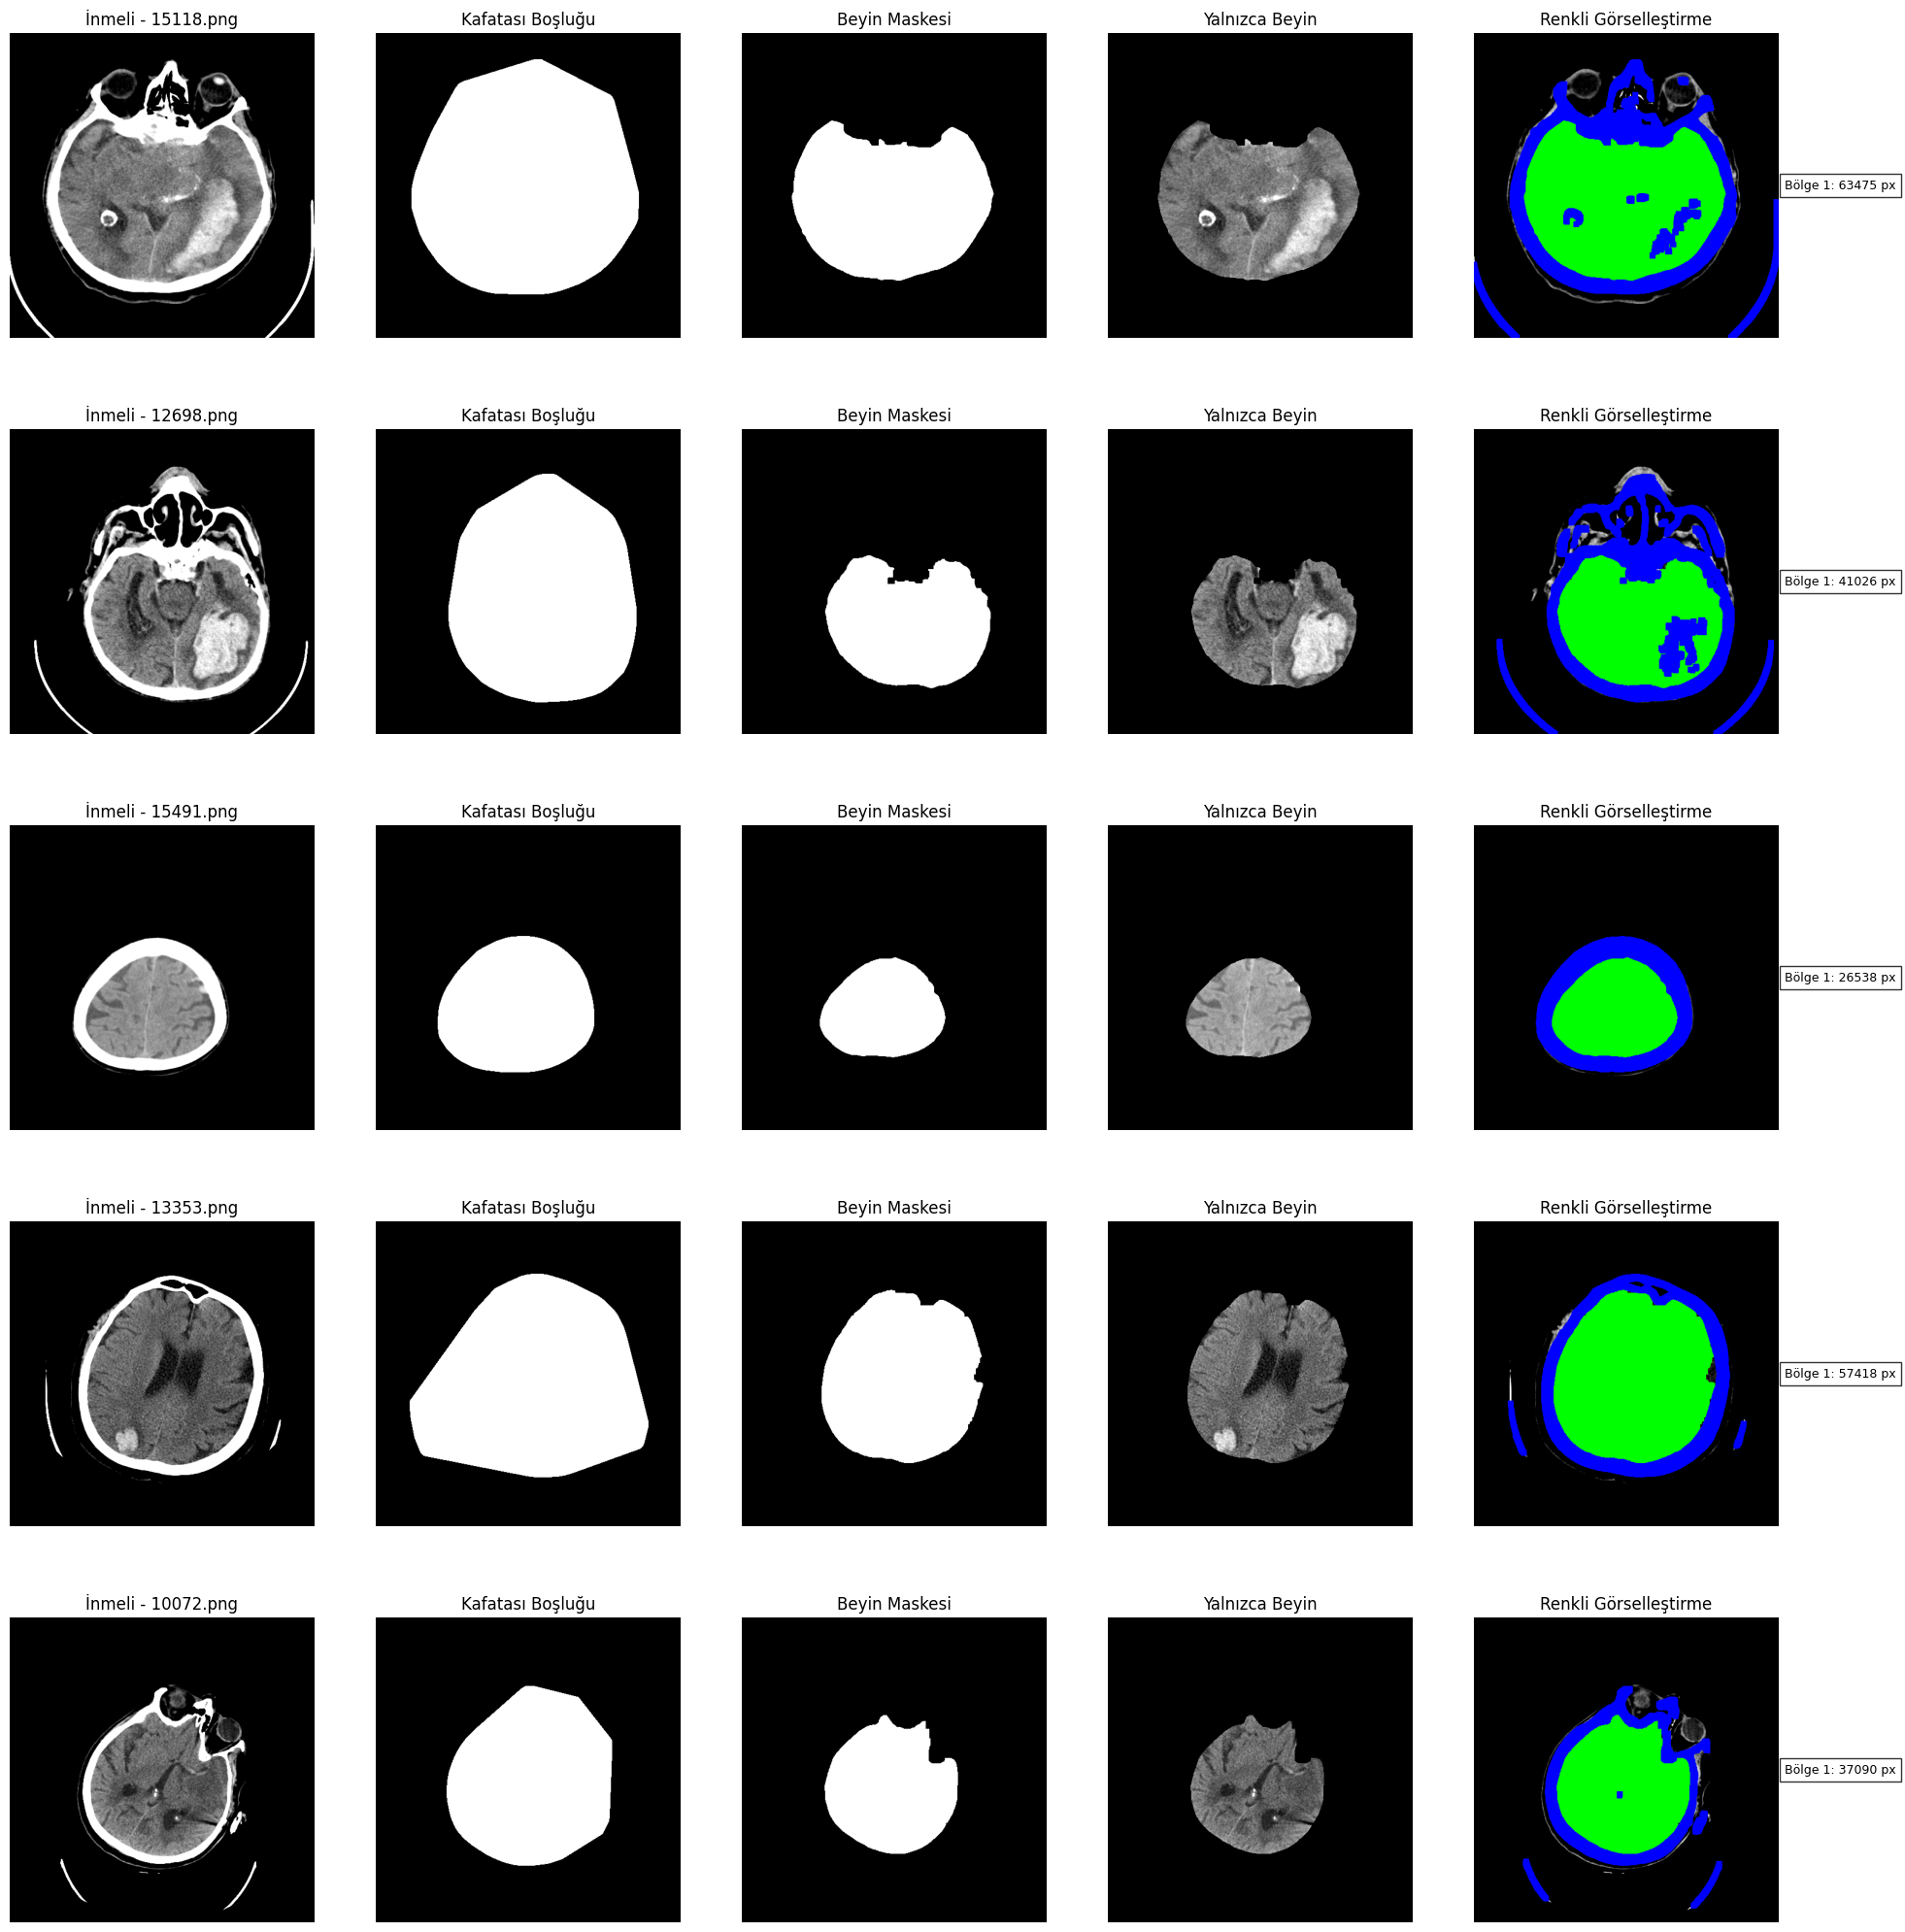

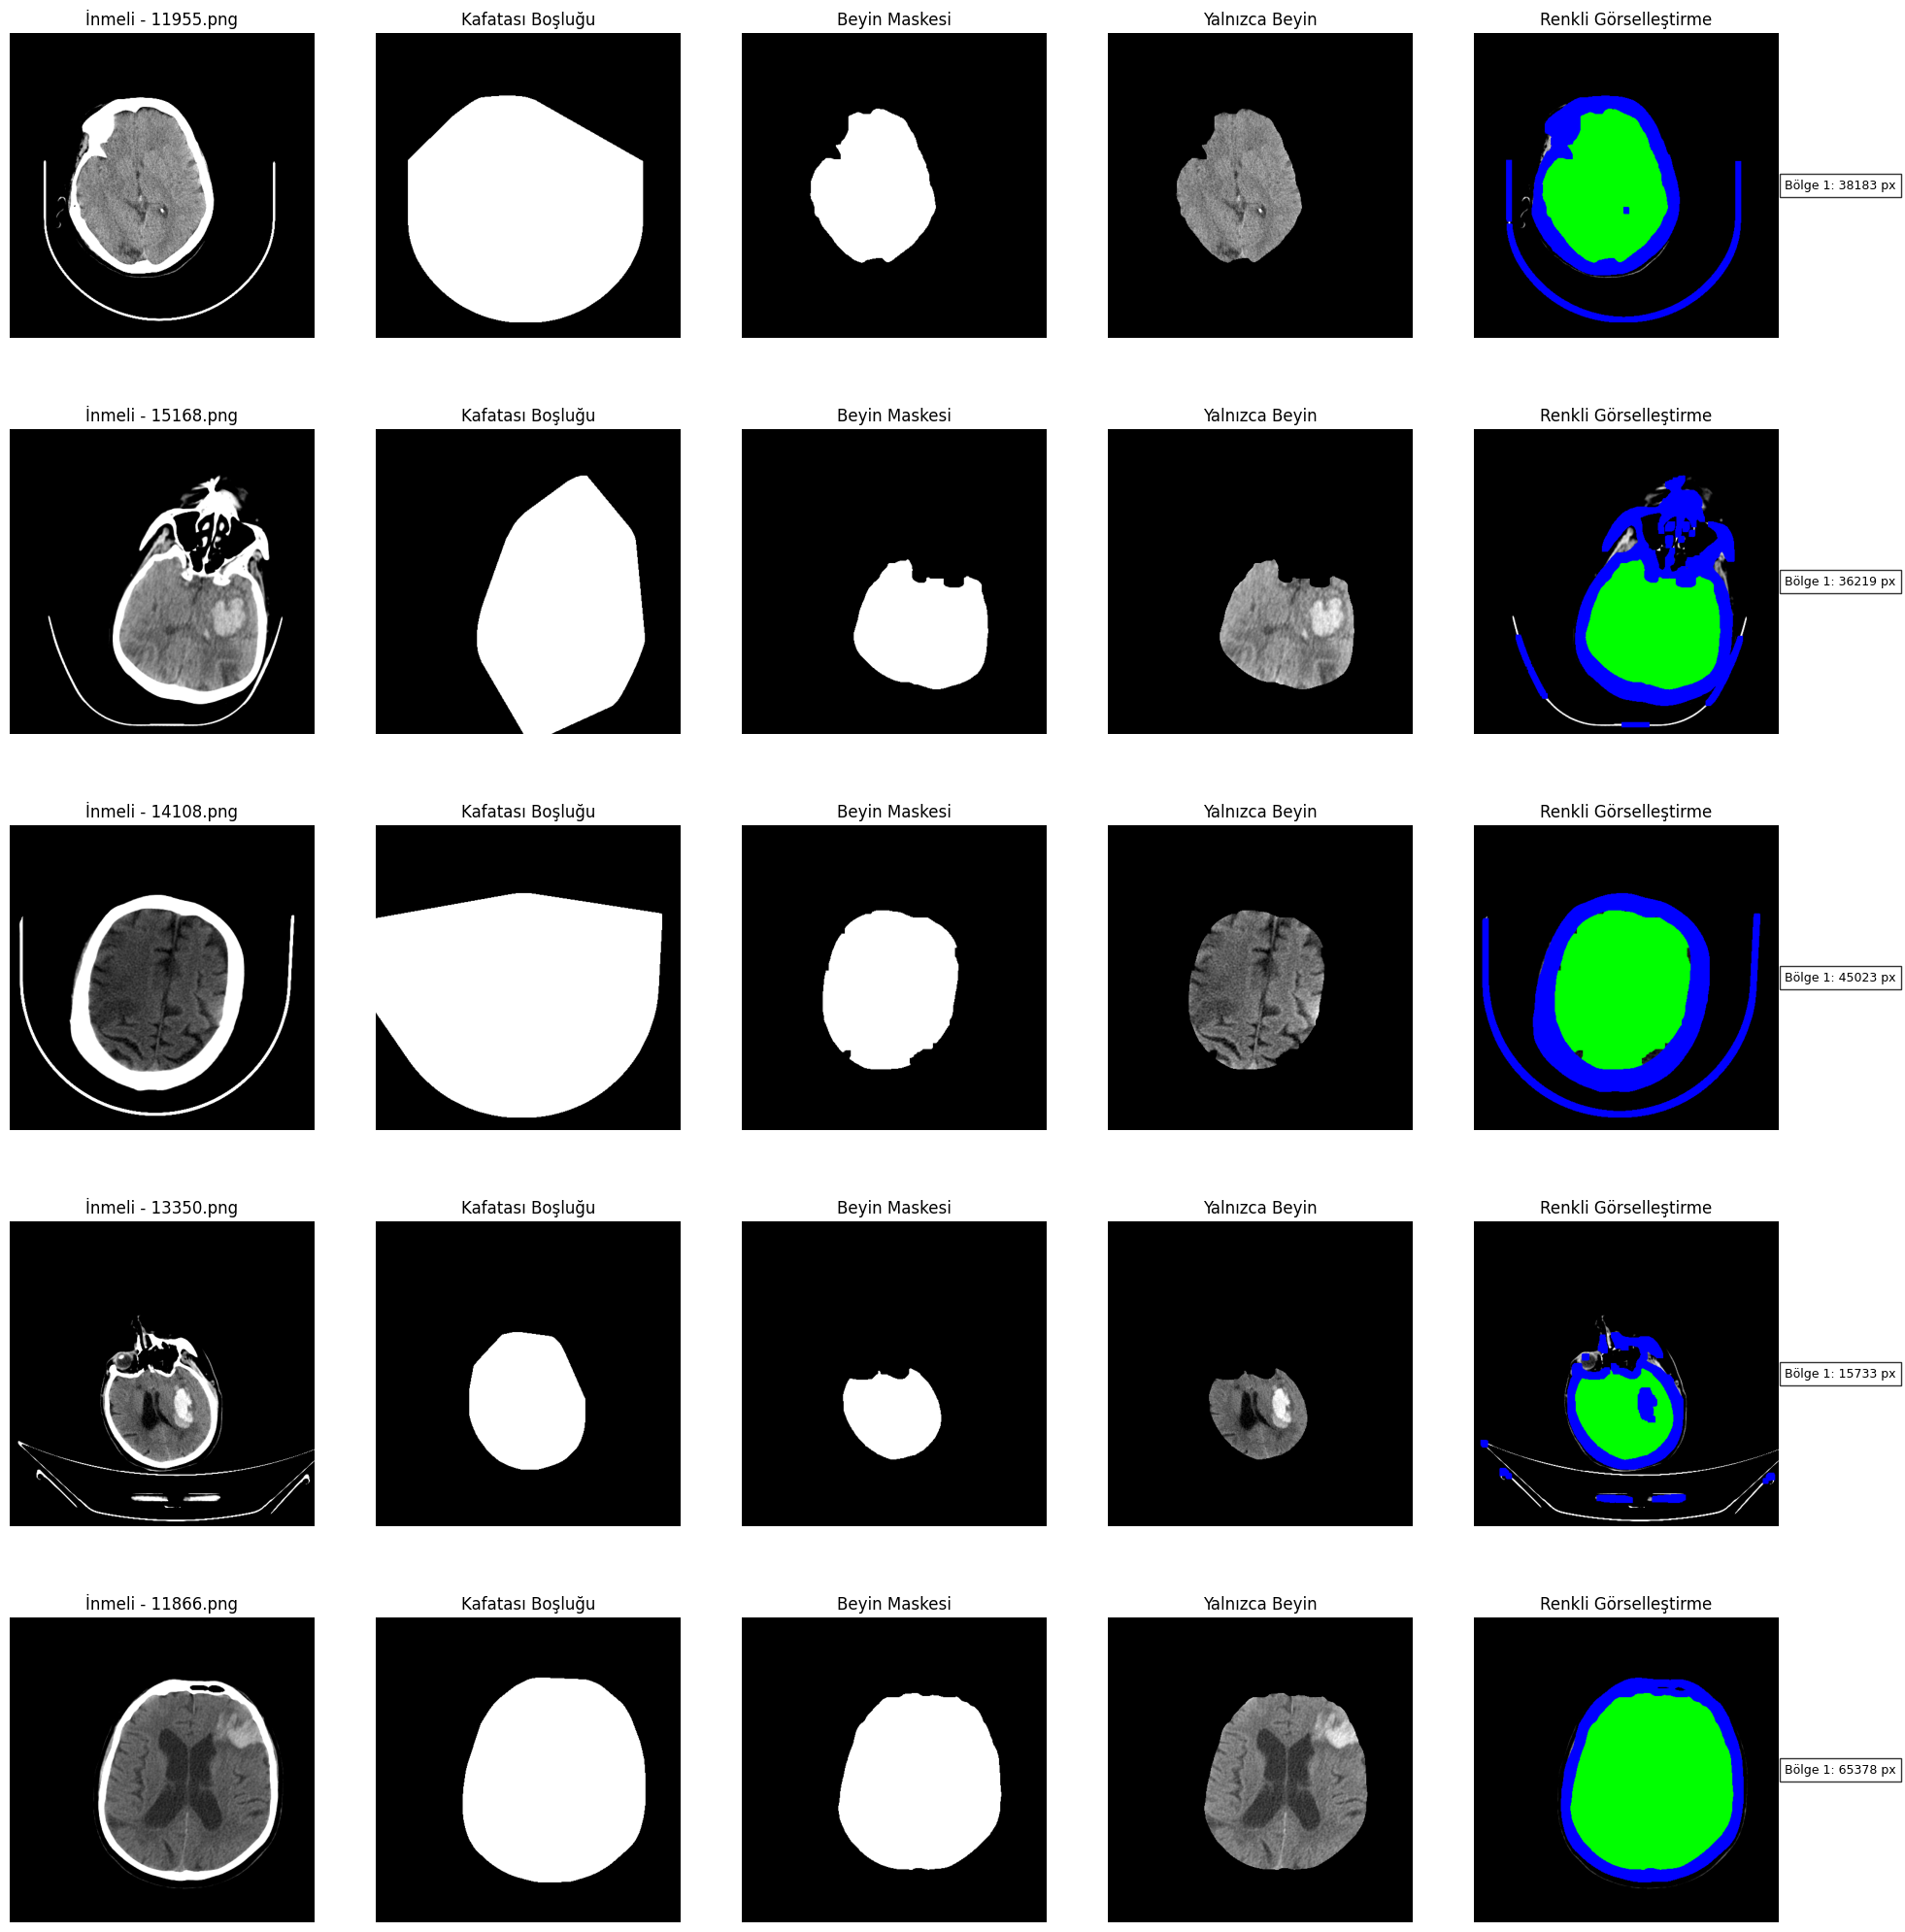

In [17]:
import os
import random
import cv2
import numpy as np
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

# Define paths to the two classes
class_0_path = "data/BeyinInmeVerisi-Siniflandirma/0"
class_1_path = "data/BeyinInmeVerisi-Siniflandirma/1"

# Get all image files from each class
class_0_files = [os.path.join(class_0_path, f) for f in os.listdir(class_0_path) if f.endswith('.png')]
class_1_files = [os.path.join(class_1_path, f) for f in os.listdir(class_1_path) if f.endswith('.png')]

# Randomly select 10 files from each class
random.seed(42)  # For reproducibility
class_0_sample = random.sample(class_0_files, 15)
class_1_sample = random.sample(class_1_files, 15)

# Combine files and process them
all_files = class_0_sample + class_1_sample

# Define a function to process a batch of files
def process_batch(file_batch):
    results = []
    for file_path in file_batch:
        # Correctly determine the class (0 or 1)
        class_name = "Sağlıklı" if "/0/" in file_path else "İnmeli"
        
        # Process the image with segment_brain_inside_skull
        result = segment_brain_inside_skull(
            file_path, 
            skull_threshold=230, 
            brain_threshold=40, 
            max_regions=3, 
            min_region_size=1800
        )
        
        if result is not None and len(result) >= 6:
            results.append((file_path, class_name, result))
    
    return results

# Process all files
all_results = process_batch(all_files)

# Display results in a grid (5 images per row)
images_per_row = 5
num_rows = (len(all_results) + images_per_row - 1) // images_per_row

for row in range(num_rows):
    start_idx = row * images_per_row
    end_idx = min(start_idx + images_per_row, len(all_results))
    row_results = all_results[start_idx:end_idx]
    
    # Create figure for this row
    fig, axes = plt.subplots(len(row_results), 5, figsize=(20, 4 * len(row_results)))
    
    # Make axes a 2D array even if there's only one image in the row
    if len(row_results) == 1:
        axes = np.array([axes])
    
    for i, (file_path, class_name, result) in enumerate(row_results):
        orig_img, skull_cavity, brain_mask, brain_only, colored_vis, selected_regions = result
        file_name = os.path.basename(file_path)
        
        # Original Image
        axes[i, 0].imshow(orig_img, cmap='gray')
        axes[i, 0].set_title(f'{class_name} - {file_name}')
        axes[i, 0].axis('off')
        
        # Skull Cavity
        axes[i, 1].imshow(skull_cavity, cmap='gray')
        axes[i, 1].set_title('Kafatası Boşluğu')
        axes[i, 1].axis('off')
        
        # Brain Mask
        axes[i, 2].imshow(brain_mask, cmap='gray')
        axes[i, 2].set_title('Beyin Maskesi')
        axes[i, 2].axis('off')
        
        # Brain Only
        axes[i, 3].imshow(brain_only, cmap='gray')
        axes[i, 3].set_title('Yalnızca Beyin')
        axes[i, 3].axis('off')
        
        # Colored Visualization
        axes[i, 4].imshow(colored_vis)
        axes[i, 4].set_title('Renkli Görselleştirme')
        axes[i, 4].axis('off')
        
        # Add region info as text
        region_info = "\n".join([f"Bölge {j+1}: {area} px" for j, (_, area) in enumerate(selected_regions)])
        axes[i, 4].text(1.02, 0.5, region_info, transform=axes[i, 4].transAxes, 
                      fontsize=9, verticalalignment='center',
                      bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.1, hspace=0.3)
    plt.show()


# En Sonki Elde Edilen Fonksiyonu Tüm Resimler Üzerinde Uygula

In [249]:
import os
import PIL

data_dir = "data\BeyinInmeVerisi-Siniflandirma"

class_names = sorted(x for x in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, x)))
num_class = len(class_names)
image_files = [
    [os.path.join(data_dir, class_names[i], x) for x in os.listdir(os.path.join(data_dir, class_names[i]))]
    for i in range(num_class)
]
num_each = [len(image_files[i]) for i in range(num_class)]
image_files_list = []
image_class = []
for i in range(num_class):
    image_files_list.extend(image_files[i])
    image_class.extend([i] * num_each[i])
num_total = len(image_class)
image_width, image_height = PIL.Image.open(image_files_list[0]).size

print(f"Total image count: {num_total}")
print(f"Image dimensions: {image_width} x {image_height}")
print(f"Label names: {class_names}")
print(f"Label counts: {num_each}")

Total image count: 6947
Image dimensions: 512 x 512
Label names: ['0', '1']
Label counts: [4564, 2383]


In [250]:
import os
import cv2

# İşlenmiş verilerin kaydedileceği klasör
output_dir = "processed_data"
os.makedirs(output_dir, exist_ok=True)

# Kategorilere göre alt klasörler oluştur
for class_name in class_names:
    os.makedirs(os.path.join(output_dir, class_name), exist_ok=True)

# Her bir resmi işle ve kaydet
for class_index, class_images in enumerate(image_files):
    for image_path in class_images:
        # Resmi işle
        results = segment_brain_inside_skull(image_path, skull_threshold=254, brain_threshold=40, max_regions=3, min_region_size=1800)

        if results is not None and len(results) >= 6:
            _, _, _, brain_only, _, _ = results

            # İşlenmiş görüntüyü kaydet
            output_path = os.path.join(output_dir, class_names[class_index], os.path.basename(image_path))
            cv2.imwrite(output_path, brain_only)

print("Tüm resimler işlendi ve kaydedildi.")

Tüm resimler işlendi ve kaydedildi.
